In [22]:
import os
from brainnetwork import load_data, preprocess_data, preprocess_spike_data
from brainnetwork import classify_by_timepoints, FI_by_timepoints_v2, FI_by_neuron_count
from brainnetwork import construct_correlation_network, compute_network_metrics_by_class
from brainnetwork.visualization import *

In [23]:
base_dir = "/beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/"
data_paths = ["M21_1107", "M71_1024", "M73_1128", "M77_1031", "M77_1107", "M78_1017", "M79_1128", "M91_1017"]
idx = 3 # Change this index to select different datasets
data_path = base_dir + data_paths[idx] # 'M77_1031'
print(f"Processing data from: {data_path}")
save_dir = "../results/" + data_paths[idx] 

data_out_dir = os.path.join(save_dir, "data")
fig_out_dir = os.path.join(save_dir, "figures")

os.makedirs(data_out_dir, exist_ok=True)
os.makedirs(fig_out_dir, exist_ok=True)

Processing data from: /beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/M77_1031


In [24]:
neuron_data, neuron_pos, start_edges, stimulus_data = load_data(data_path)
segments_spi, labels_spi, neuron_pos_spi = preprocess_spike_data(
        neuron_data,
        neuron_pos,
        start_edges,
        stimulus_data,
    )
neuron_data_flo, neuron_pos_flo, start_edges_flo, stimulus_data_flo = load_data(data_path, data_type='fluorescence')
segments_flo, labels_flo, neuron_pos_flo = preprocess_data(
    neuron_data_flo,
    neuron_pos_flo,
    start_edges_flo,
    stimulus_data_flo,
)

原始神经数据形状: (7681, 35896)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 376 个 RR 神经元
  - 类别 2 贡献了 364 个 RR 神经元
  - 类别 3 贡献了 345 个 RR 神经元
三类并集后共筛选出 711 个唯一 RR 神经元
原始神经数据形状: (7681, 35953)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 686 个 RR 神经元
  - 类别 2 贡献了 798 个 RR 神经元
  - 类别 3 贡献了 671 个 RR 神经元
三类并集后共筛选出 1308 个唯一 RR 神经元


In [25]:
# %% 可视化相关函数定义
from tifffile import imread 
import numpy as np
import scipy.stats as stats

def rr_distribution_plot_pretty(neuron_pos, neuron_pos_rr, data_path,
                                x_total_mm=7.0,
                                scalebar_mm=1.0,
                                gamma=1.25,
                                bg_p_low=2,
                                bg_p_high=98):
    """
    优化版 RR neuron distribution plot
    - All neurons: 用密度图(hist2d)避免点重叠
    - RR neurons: 散点+白色描边更清楚
    - 去坐标轴：保留比例尺（X轴总长=7mm）
    - 背景：更柔和对比度 + gamma 压亮度
    """
    from matplotlib.colors import LogNorm
    from matplotlib.patches import Rectangle
    fig, ax = plt.subplots(figsize=(8.5, 7), dpi=200)

    # --- 背景图像 ---
    brain_img = imread(f"{data_path}/whole_brain_3d.tif")
    mid_slice = brain_img[brain_img.shape[0] // 4, :, :].astype(np.float32)

    # normalize to [0,1]
    mid_slice = mid_slice - np.nanmin(mid_slice)
    mid_slice = mid_slice / (np.nanmax(mid_slice) + 1e-8)

    # 温和对比度拉伸（避免过强）
    vmin = np.percentile(mid_slice, bg_p_low)
    vmax = np.percentile(mid_slice, bg_p_high)
    bg = np.clip((mid_slice - vmin) / (vmax - vmin + 1e-8), 0, 1)

    # gamma > 1 会压暗中高亮区域（整体不那么亮、对比不刺）
    if gamma is not None:
        bg = bg ** gamma

    ax.imshow(bg, cmap="gray", interpolation="nearest")

    # =======================
    # All neurons（散点，极轻）
    # =======================
    ax.scatter(
        neuron_pos[1, :],
        neuron_pos[0, :],
        s=10,                    # 非常小
        c="#6B7B61",               # 冷灰
        alpha=0.3,             # 极低透明度
        marker="o",
        linewidths=0,
        rasterized=True,        # 导出 PDF 非常重要
        zorder=2
    )


    # --- RR neurons：散点更醒目 + 描边 ---
    x_rr = neuron_pos_rr[1, :]
    y_rr = neuron_pos_rr[0, :]

    ax.scatter(
        x_rr, y_rr,
        s=40,
        c="#1ada4a",
        alpha=0.9,
        linewidths=0.6,
        edgecolors="#000000",   # 白描边让红点从背景里“跳出来”
        zorder=5
    )

    # --- 去掉坐标轴/网格/边框 ---
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # --- 比例尺（X轴总长=7mm） ---
    # 像素->mm：整张图宽 bg.shape[1] 像素对应 x_total_mm mm
    px_per_mm = bg.shape[1] / x_total_mm
    bar_px = scalebar_mm * px_per_mm

    # 放在右下角，留一点边距
    pad = 0.04
    x0 = bg.shape[1] * (1 - pad) - bar_px
    y0 = bg.shape[0] * (1 - pad)

    bar_h = max(6, int(bg.shape[0] * 0.004))  # 比例尺厚度随图大小自适应
    ax.add_patch(Rectangle((x0, y0 - bar_h), bar_px, bar_h,
                           facecolor="white", edgecolor="none", zorder=10))
    ax.text(x0 + bar_px / 2, y0 - bar_h - 15,
            f"{scalebar_mm:g} mm",
            color="white", ha="center", va="bottom",
            fontsize=11, weight="bold", zorder=10)

    # --- 标题（可选：如果你也想去掉标题，把下一行注释掉） ---
    # ax.set_title("RR Neuron Distribution", fontsize=16, pad=10)

    plt.tight_layout()
    save_path = os.path.join(fig_out_dir, "rr_distribution.png")
    fig.savefig(save_path, dpi=300)
    plt.show()

def plot_rr_population_average(segments, labels, t_stimulus = 10, l_stimulus = 20, l_last=20):
    """Plot average responses of all RR neurons to three stimulus types"""
    # Class name mapping
    CLASS_NAMES = {
        3: "Random",
        1: "Convergent",
        2: "Divergent"
    }

    # Unified color scheme
    CLASS_COLORS = {
        1: "#3D5A80",      # Random - deep blue
        2: "#E07A5F",      # Convergent - coral orange
        3: "#81B29A"       # Divergent - sage green
    }

    time_axis = np.arange(segments.shape[2])
    stim_start = t_stimulus
    stim_duration = l_stimulus
    stim_end = stim_start + stim_duration + l_last

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Add elegant stimulus window shading
    ax.axvspan(stim_start, stim_end, color='#FFD166', alpha=0.15, zorder=0, label='Stimulus')
    ax.axhline(y=0, color='#888888', linestyle='-', linewidth=0.5, alpha=0.4, zorder=0)

    # Plot each stimulus type
    for cls in [1, 2, 3]:  # Only plot the three main classes
        cls_mask = labels == cls
        if not np.any(cls_mask):
            continue

        # Get all trials for this class, average across neurons AND trials
        cls_segments = segments[cls_mask]  # (n_trials, n_neurons, n_timepoints)

        # Average across both trials and neurons to get population mean
        population_mean = np.mean(cls_segments, axis=(0, 1))  # (n_timepoints,)

        # Calculate SEM across trials (keeping neurons separate first)
        trial_means = np.mean(cls_segments, axis=1)  # (n_trials, n_timepoints)
        population_sem = stats.sem(trial_means, axis=0, nan_policy='omit')

        color = CLASS_COLORS[cls]
        class_name = CLASS_NAMES[cls]

        # Plot with error band
        ax.fill_between(time_axis,
                       population_mean - population_sem,
                       population_mean + population_sem,
                       color=color, alpha=0.2, zorder=1)
        ax.plot(time_axis, population_mean, color=color, linewidth=2.5,
               label=class_name, zorder=2)

    # Styling
    ax.set_xlabel('Time (frames)', fontsize=13, fontweight='medium')
    ax.set_ylabel('Mean dF/F', fontsize=13, fontweight='medium')
    ax.set_title('Population Average Response of RR Neurons',
                fontsize=15, fontweight='bold', pad=15)
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.legend(frameon=True, fontsize=11, loc='upper right',
             framealpha=0.95, edgecolor='#cccccc')

    fig.tight_layout()
    save_path = os.path.join(fig_out_dir, "rr_population_average.png")
    fig.savefig(save_path, dpi=300)
    plt.show()

def plot_rr_population_average_pretty(
    segments, labels,
    t_stimulus=10, l_stimulus=20, 
    figsize=(6.4, 4.2),   # 整体缩小
    line_width=3.6,       # 曲线加粗
    sem_alpha=0.18        # 阴影更柔
):
    """Plot average responses of all RR neurons to three stimulus types (beautified)"""

    # 类名（保持你的逻辑）
    CLASS_NAMES = {1: "Convergent", 2: "Divergent", 3: "Random"}

    # 更舒服、对比清晰（接近 Okabe-Ito / colorblind-friendly）
    CLASS_COLORS = {
        1: "#1F77B4",  # 蓝
        2: "#D55E00",  # 橙红（更高级的橙）
        3: "#009E73",  # 绿
    }

    time_axis = np.arange(segments.shape[2])
    stim_start = t_stimulus
    stim_end = stim_start + l_stimulus

    fig, ax = plt.subplots(figsize=figsize, dpi=200)

    # ========= 只保留左/下坐标轴 =========
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="both", top=False, right=False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    # 先算出全局 y 范围（为了把刺激条放在曲线下方且不挡曲线）
    # （先不画，先粗算一个 y_min/y_max）
    # 给一个保守的范围：后面再用实际数据更新也行
    y_min_guess = np.nanmin(segments)
    y_max_guess = np.nanmax(segments)

    # ========= 画曲线 =========
    for cls in [1, 2, 3]:
        cls_mask = labels == cls
        if not np.any(cls_mask):
            continue

        cls_segments = segments[cls_mask]  # (n_trials, n_neurons, n_timepoints)

        population_mean = np.nanmean(cls_segments, axis=(0, 1))
        trial_means = np.nanmean(cls_segments, axis=1)  # (n_trials, n_timepoints)
        population_sem = stats.sem(trial_means, axis=0, nan_policy="omit")

        color = CLASS_COLORS[cls]
        name = CLASS_NAMES[cls]

        ax.fill_between(
            time_axis,
            population_mean - population_sem,
            population_mean + population_sem,
            color=color, alpha=sem_alpha, linewidth=0, zorder=1
        )
        ax.plot(
            time_axis, population_mean,
            color=color, linewidth=line_width, solid_capstyle="round",
            label=name, zorder=3
        )

    # 重新用当前轴内容拿到更准确的 y 范围
    y_min, y_max = ax.get_ylim()
    yr = y_max - y_min

    # ========= 刺激条：曲线下方小灰色横向柱子 =========
    # 放在底部上方一点点，留出空间
    bar_h = 0.035 * yr
    bar_y = y_min + 0.06 * yr  # 距离底部一点点
    ax.broken_barh(
        [(stim_start, l_stimulus)],
        (bar_y, bar_h),
        facecolors="#9E9E9E",
        edgecolors="none",
        alpha=0.9,
        zorder=0
    )
    ax.text(
        stim_start + l_stimulus / 2,
        bar_y + bar_h + 0.015 * yr,
        "Stimulus",
        ha="center", va="bottom",
        fontsize=10, color="#666666"
    )

    # ========= 标签与标题 =========
    ax.set_xlabel("Time (frames)", fontsize=12)
    ax.set_ylabel("Mean dF/F", fontsize=12)
    # ax.set_title("Population Average Response of RR Neurons",
    #             fontsize=13.5, weight="bold", pad=10)

    # 更干净的 legend
    leg = ax.legend(
        frameon=False, fontsize=10.5, loc="upper right",
        handlelength=2.4
    )

    ax.margins(x=0.02)
    fig.tight_layout()
    save_path = os.path.join(fig_out_dir, "rr_population_average.png")
    fig.savefig(save_path, dpi=300)
    plt.show()

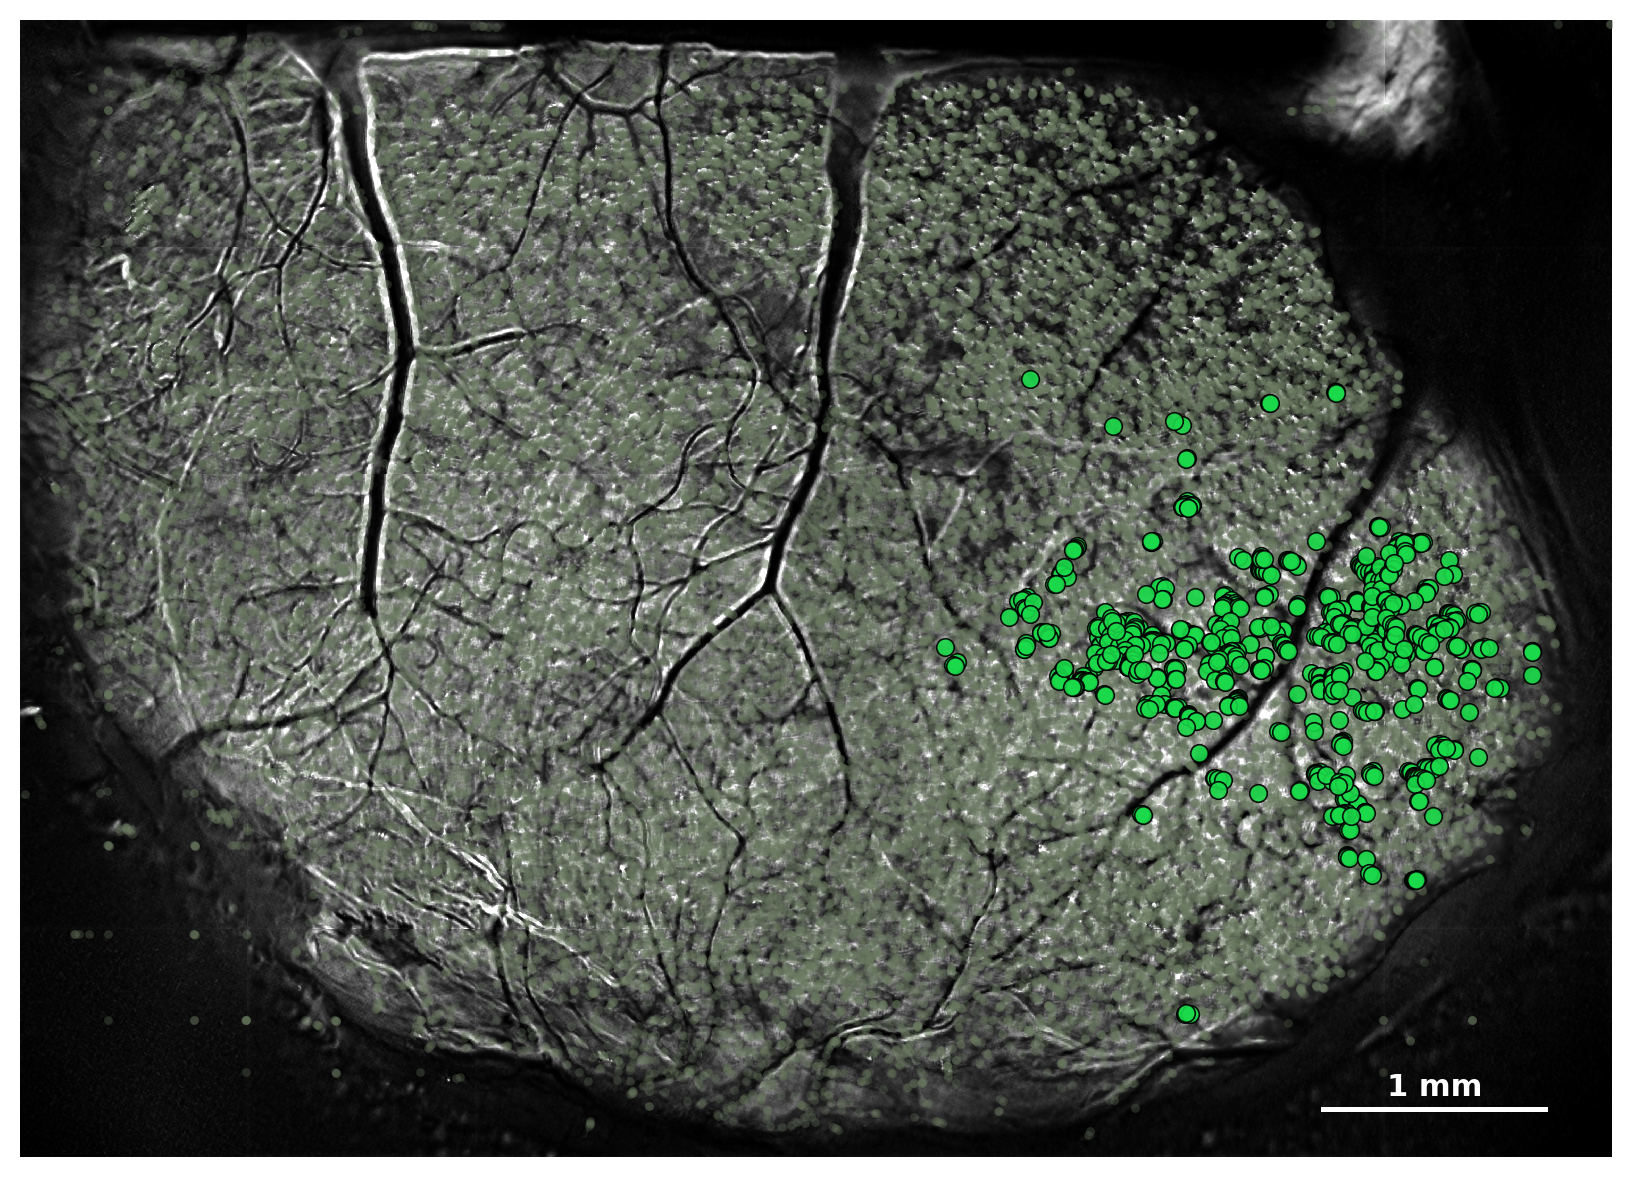

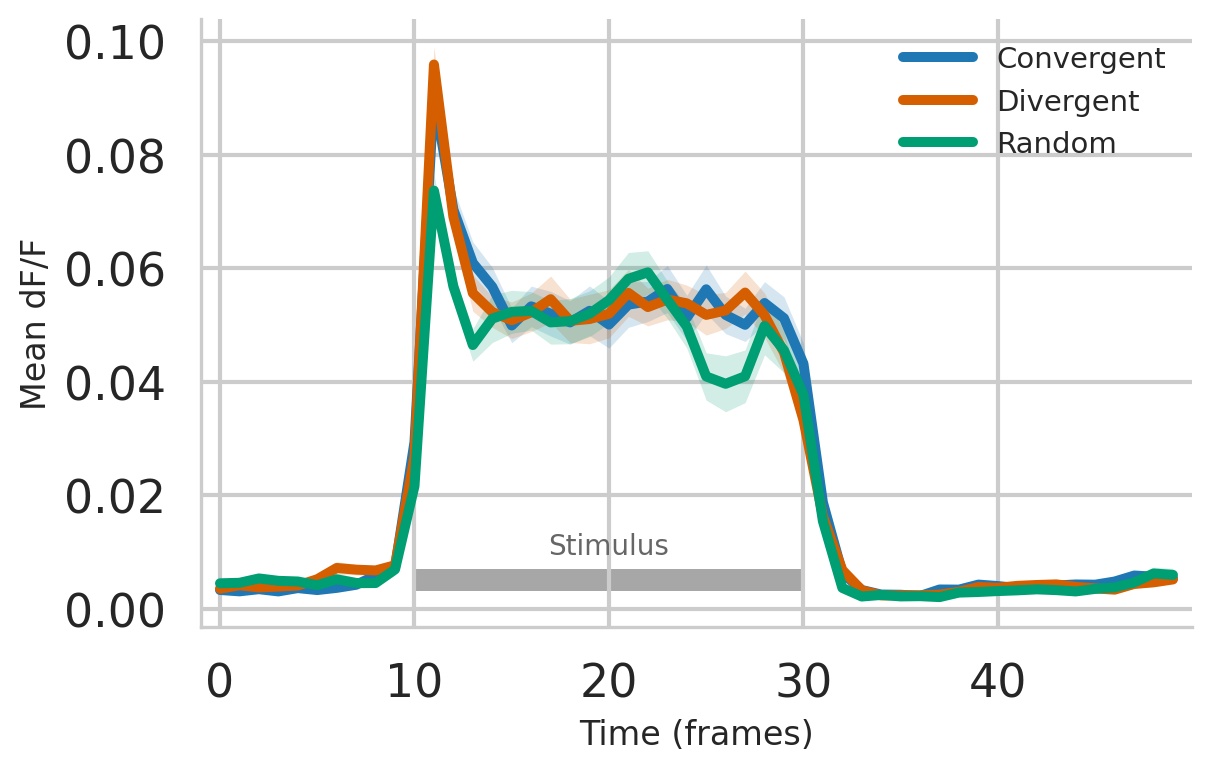

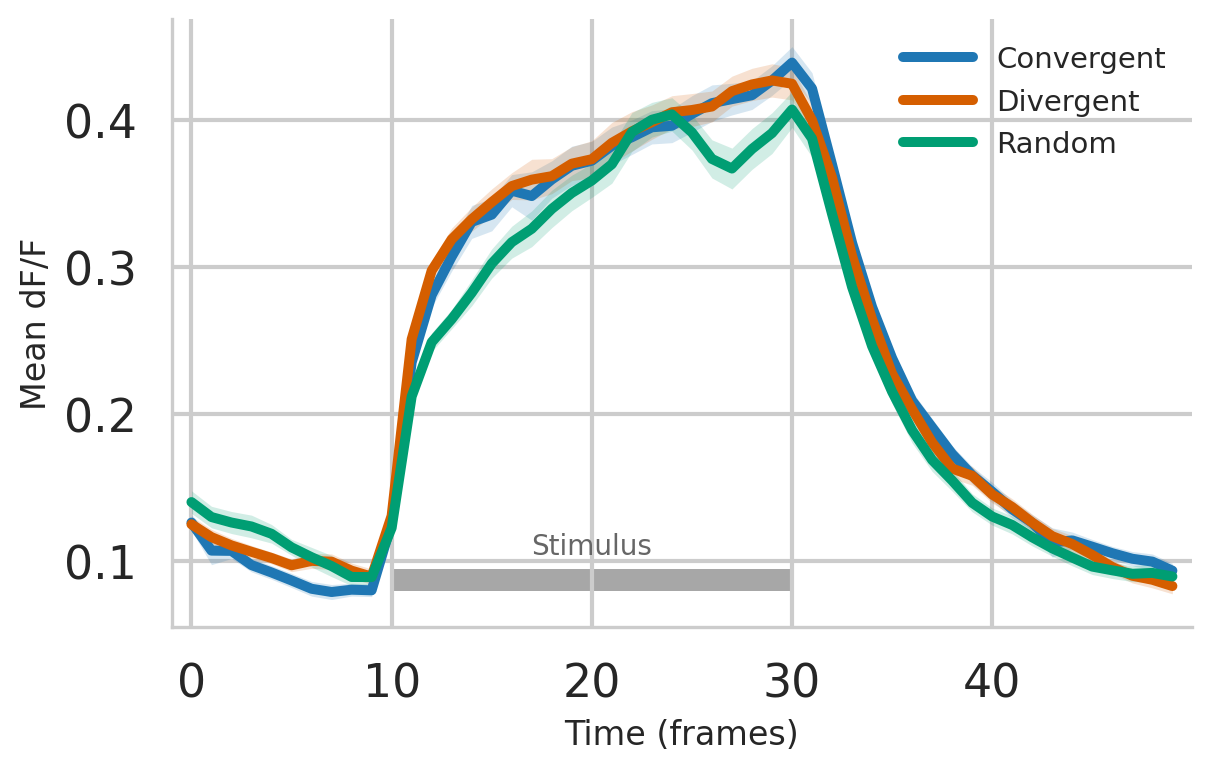

In [26]:
try:
    rr_distribution_plot_pretty(neuron_pos, neuron_pos_spi, data_path, gamma=1.1)
except Exception as e:
    print(f"Error occurred while plotting RR distribution for spike data: {e}")

# rr_distribution_plot_pretty(neuron_pos_flo, neuron_pos_flo, data_path, gamma=1.1)

#plot_rr_population_average(segments_spi, labels_spi)
#plot_rr_population_average(segments_flo, labels_flo)
plot_rr_population_average_pretty(segments_spi, labels_spi)
plot_rr_population_average_pretty(segments_flo, labels_flo)

In [27]:
accuracies, time_points, accuracy_std, n_folds = classify_by_timepoints(segments_flo, labels_flo)
labels_shuffled = np.random.permutation(labels_flo)
accuracies_shu, time_points_shu, accuracy_std_shu, n_folds_shu = classify_by_timepoints(segments_flo, labels_shuffled)

fisher_mv, time_points_fi_mv = FI_by_timepoints_v2(segments_flo, 
                                                   labels_flo, 
                                                   mode="multivariate", 
                                                   reduction=None)
fisher_uv, time_points_fi_uv = FI_by_timepoints_v2(segments_flo, labels_flo, mode="univariate", reduction="mean")
neuron_counts, fi_values = FI_by_neuron_count(segments_flo, labels_flo)

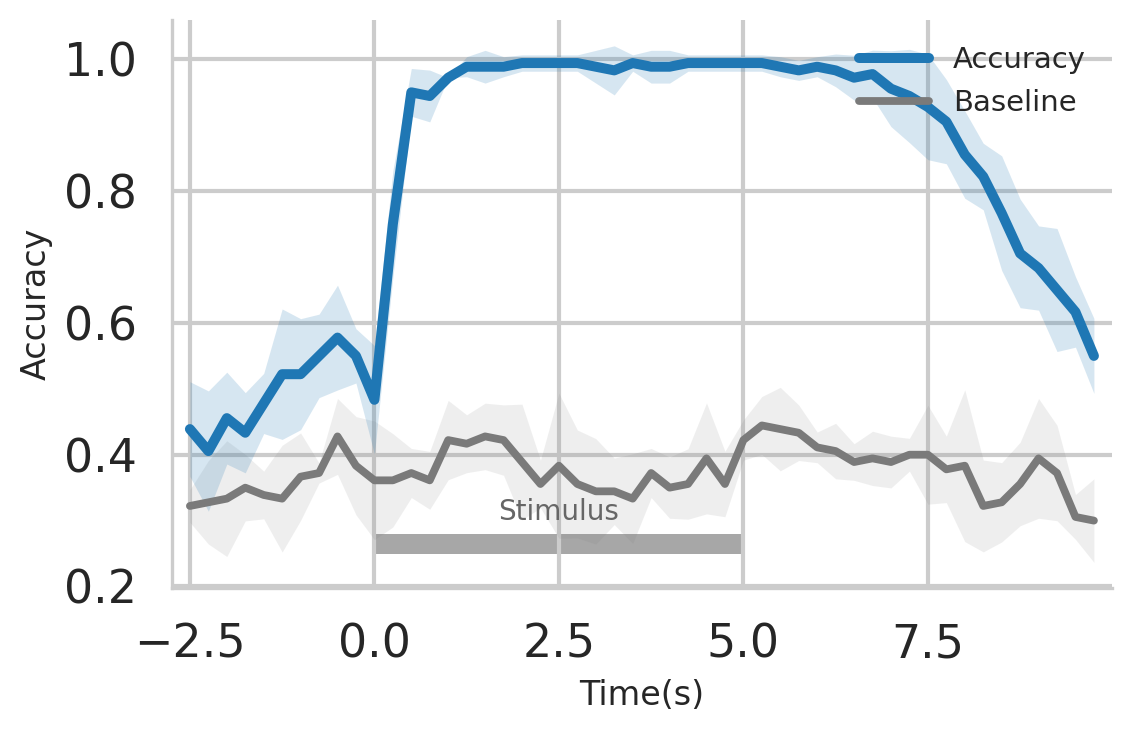

In [28]:
plot_accuracy(time_points=time_points, accuracies=accuracies, baseline=accuracies_shu, accuracy_std=accuracy_std, baseline_std=accuracy_std_shu, save_path=os.path.join(fig_out_dir, "classification_accuracy.png"))

In [29]:
nx_result = compute_network_metrics_by_class(segments_spi, labels_spi, neuron_pos_spi, do_bootstrap=False)

In [30]:
def plot_correlation_violin_optim(nx_result):
    """
    Plot violin plots of correlation coefficient distributions for each stimulus class.
    nx_result: dict
        Output from compute_network_metrics_by_class containing 'corr_matrix' for each class.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # 类名定义
    CLASS_NAMES = {1: "Convergent", 2: "Divergent", 3: "Random"}
    CLASS_COLORS = {
        1: "#3C5488",  # Convergent: 深蓝 (沉稳，表示汇聚)
        2: "#E64B35",  # Divergent:  朱红 (醒目，表示发散)
        3: "#00A087",  # Random:     蓝绿 (中性，表示随机)
    }
    # 提取每个类别的相关系数（排除对角线）
    corr_data = []
    class_labels = []
    class_order = [1, 2, 3]

    for cls in class_order:
        if cls in nx_result:
            corr_matrix = nx_result[cls]['corr_matrix']
            # 获取上三角的相关系数（排除对角线）
            mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
            corr_values = corr_matrix[mask]
            corr_data.append(corr_values)
            class_labels.append(CLASS_NAMES[cls])

    # 绘制小提琴图
    fig, ax = plt.subplots(figsize=(4, 3), dpi=200)

    # 创建小提琴图
    parts = ax.violinplot(
        corr_data,
        positions=range(len(class_order)),
        widths=0.7,
        showmeans=True,
        showmedians=True,
    )

    # 为每个小提琴设置颜色
    for i, pc in enumerate(parts['bodies']):
        cls = class_order[i]
        pc.set_facecolor(CLASS_COLORS[cls])
        pc.set_alpha(0.7)
        pc.set_edgecolor(CLASS_COLORS[cls])
        pc.set_linewidth(1.2)

    # 设置其他线条的样式
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
        if partname in parts:
            vp = parts[partname]
            vp.set_edgecolor('#333333')
            vp.set_linewidth(1.2)

    # 坐标轴美化
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    # 设置 x 轴标签
    ax.set_xticks(range(len(class_order)))
    ax.set_xticklabels(class_labels, fontsize=11)

    # 标签和标题
    ax.set_ylabel('Correlation Coefficient', fontsize=12)
    # ax.set_xlabel('Stimulus Type', fontsize=12)
    # ax.set_title('Distribution of Pairwise Correlations', fontsize=13.5, weight='bold', pad=10)

    # 添加水平参考线
    ax.axhline(y=0, color='#888888', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)

    fig.tight_layout()
    save_path = os.path.join(fig_out_dir, "correlation_violin.png")
    fig.savefig(save_path, dpi=300)
    plt.show()

def plot_network_metrics_bars_optim(
    nx_result,
    metrics=None,
    figsize=(8, 4),
    bar_width=0.6,
    show_values=True,
    value_fontsize=9
):
    """
    绘制网络指标的柱状图
    
    Parameters
    ----------
    nx_result : dict
        compute_network_metrics_by_class 的返回结果
    metrics : list of str, optional
        要绘制的指标列表。如果为 None，则绘制所有可用指标。
        可选指标：
        - 'density': 网络密度
        - 'mean_degree': 平均度
        - 'largest_component': 最大连通分量大小
        - 'avg_clustering': 平均聚类系数
        - 'global_efficiency': 全局效率
        - 'local_efficiency': 局部效率
        - 'transitivity': 传递性
        - 'efficiency': 效率（额外计算）
        - 'modularity': 模块度
        - 'betweenness_mean': 介数中心性均值
    figsize : tuple
        图形大小
    bar_width : float
        柱子宽度
    show_values : bool
        是否在柱子上显示数值
    value_fontsize : int
        数值字体大小
    """
    
    # 类名定义
    CLASS_NAMES = {1: "Convergent", 2: "Divergent", 3: "Random"}
    CLASS_COLORS = {
        1: "#3C5488",  # Convergent: 深蓝 (沉稳，表示汇聚)
        2: "#E64B35",  # Divergent:  朱红 (醒目，表示发散)
        3: "#00A087",  # Random:     蓝绿 (中性，表示随机)
    }
    
    # 默认绘制所有指标
    if metrics is None:
        metrics = [
            'density', 'mean_degree', 'largest_component',
            'avg_clustering', 'global_efficiency', 'local_efficiency',
            'transitivity', 'efficiency', 'modularity', 'betweenness_mean'
        ]
    
    # 指标的显示名称
    metric_labels = {
        'density': 'Network Density',
        'mean_degree': 'Mean Degree',
        'largest_component': 'Largest Component',
        'avg_clustering': 'Avg Clustering',
        'global_efficiency': 'Global Efficiency',
        'local_efficiency': 'Local Efficiency',
        'transitivity': 'Transitivity',
        'efficiency': 'Efficiency',
        'modularity': 'Modularity',
        'betweenness_mean': 'Betweenness (mean)',
    }
    
    class_order = [1, 2, 3]
    n_metrics = len(metrics)
    n_cols = 3
    n_rows = (n_metrics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, dpi=200)
    axes = axes.flatten() if n_metrics > 1 else [axes]
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        # 提取数据
        values = []
        colors = []
        labels = []
        
        for cls in class_order:
            if cls not in nx_result:
                continue
                
            # 从不同的字段中获取指标值
            if metric in ['density', 'mean_degree', 'largest_component', 
                         'avg_clustering', 'global_efficiency', 'local_efficiency', 
                         'transitivity']:
                value = nx_result[cls]['summary'][metric]
            elif metric == 'efficiency':
                value = nx_result[cls]['efficiency']
            elif metric == 'modularity':
                value = nx_result[cls]['modularity']
            elif metric == 'betweenness_mean':
                value = nx_result[cls]['betweenness_stats']['mean']
            else:
                continue
            
            values.append(value)
            colors.append(CLASS_COLORS[cls])
            labels.append(CLASS_NAMES[cls])
        
        # 绘制柱状图
        x_pos = np.arange(len(values))
        bars = ax.bar(x_pos, values, width=bar_width, color=colors, 
                     alpha=0.8, edgecolor='#333333', linewidth=1.2)
        
        # 在柱子上显示数值
        if show_values:
            for i, (bar, val) in enumerate(zip(bars, values)):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width() / 2., height,
                       f'{val:.3f}',
                       ha='center', va='bottom',
                       fontsize=value_fontsize, color='#333333')
        
        # 坐标轴美化
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.2)
        ax.spines["bottom"].set_linewidth(1.2)
        
        # 设置 x 轴标签
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, fontsize=10)
        
        # 标题
        ax.set_title(metric_labels.get(metric, metric), 
                    fontsize=11, weight='bold', pad=8)
        ax.set_ylabel('Value', fontsize=10)
        
        # y 轴从 0 开始
        ax.set_ylim(bottom=0)
    
    # 隐藏多余的子图
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)
    
    fig.tight_layout()
    save_path = os.path.join(fig_out_dir, "network_metrics_bars.png")
    fig.savefig(save_path, dpi=300)
    plt.show()




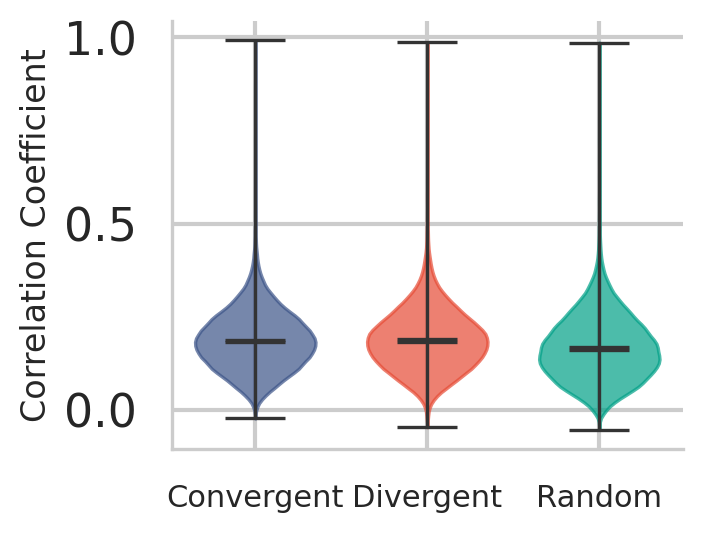

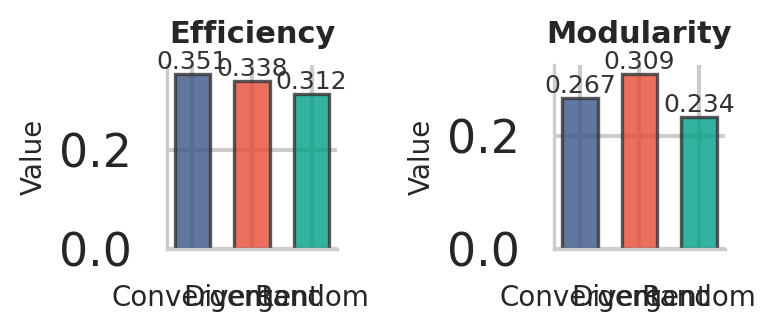

In [31]:
plot_correlation_violin_optim(nx_result)
plot_network_metrics_bars_optim(nx_result, metrics=['efficiency', 'modularity'], figsize=(6,2))


In [32]:
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer

def entropy_from_counts(counts):
    p = counts / counts.sum()
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def joint_entropy_discrete(mat_2d_int):
    """
    mat_2d_int: shape (N, d), discrete ints
    """
    _, counts = np.unique(mat_2d_int, axis=0, return_counts=True)
    return entropy_from_counts(counts)

def o_information_discrete(X_int):
    """
    X_int: shape (N, n), discrete ints
    """
    N, n = X_int.shape
    H_joint = joint_entropy_discrete(X_int)

    # sum H(X_i)
    H_single_sum = 0.0
    for i in range(n):
        H_single_sum += joint_entropy_discrete(X_int[:, i:i+1])

    # sum H(X_{-i})
    H_minus_sum = 0.0
    all_idx = np.arange(n)
    for i in range(n):
        idx = all_idx[all_idx != i]
        H_minus_sum += joint_entropy_discrete(X_int[:, idx])

    Omega = (n - 2) * H_joint + H_single_sum - H_minus_sum
    return Omega

def omega_timecourse_discretize(data, n_bins=4, strategy="quantile"):
    """
    data: (N, n, t) continuous
    returns: Omega_t (t,)
    """
    N, n, t = data.shape
    Omega_t = np.zeros(t)

    disc = KBinsDiscretizer(
        n_bins=n_bins,
        encode="ordinal",
        strategy="quantile",
        quantile_method="averaged_inverted_cdf"
    )

    for k in range(t):
        X = data[:, :, k]  # (N, n)

        # 可选：按列z-score（常见做法，减少量纲差异）
        Xz = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-12)

        # 每个时间点都用该时间点的样本分布来fit分箱
        X_int = disc.fit_transform(Xz).astype(np.int64)

        Omega_t[k] = o_information_discrete(X_int)

    return Omega_t


def omega_timecourse_subsample(data, k=80, n_repeat=10, n_bins=3):
    N, n, t = data.shape
    Omega_mean = np.zeros(t)
    Omega_sem = np.zeros(t)

    for tt in range(t):
        Omegas = []
        for _ in range(n_repeat):
            idx = np.random.choice(n, k, replace=False)
            X = data[:, idx, tt]   # (N, k)
            disc = KBinsDiscretizer(
                n_bins=n_bins,
                encode="ordinal",
                strategy="quantile",
                quantile_method="averaged_inverted_cdf"
            )
            X_int = disc.fit_transform(X).astype(np.int64)

            Omegas.append(o_information_discrete(X_int))
        Omega_mean[tt] = np.mean(Omegas)
        Omega_sem[tt] = np.std(Omegas) / np.sqrt(n_repeat)

    return Omega_mean, Omega_sem

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trial 聚合：计算每个 Trial 的平均活动
# 假设 X_trials 的形状是 (Trial总数, 帧数, 神经元数)
X_trial_averaged = np.mean(segments_spi[:, :, 10:13], axis=2) # 得到 (n_trials, n_neurons)

unique_labels = np.unique(labels_spi)
min_count = min(np.sum(labels_spi == l) for l in unique_labels)

# 2. 平衡数据集
X_balanced_list = []
labels_balanced = []

for label in unique_labels:
    mask = (labels_spi == label)
    X_label = X_trial_averaged[mask]
    
    # 建议：随机采样而非固定取前几个
    indices = np.random.choice(len(X_label), min_count, replace=False)
    X_sampled = X_label[indices]
    
    X_balanced_list.append(X_sampled)
    labels_balanced.extend([label] * min_count)

# 2. 关键修正：将列表转化为单一矩阵 [cite: 1]
X_trial_averaged_balanced = np.vstack(X_balanced_list)
labels_balanced = np.array(labels_balanced)


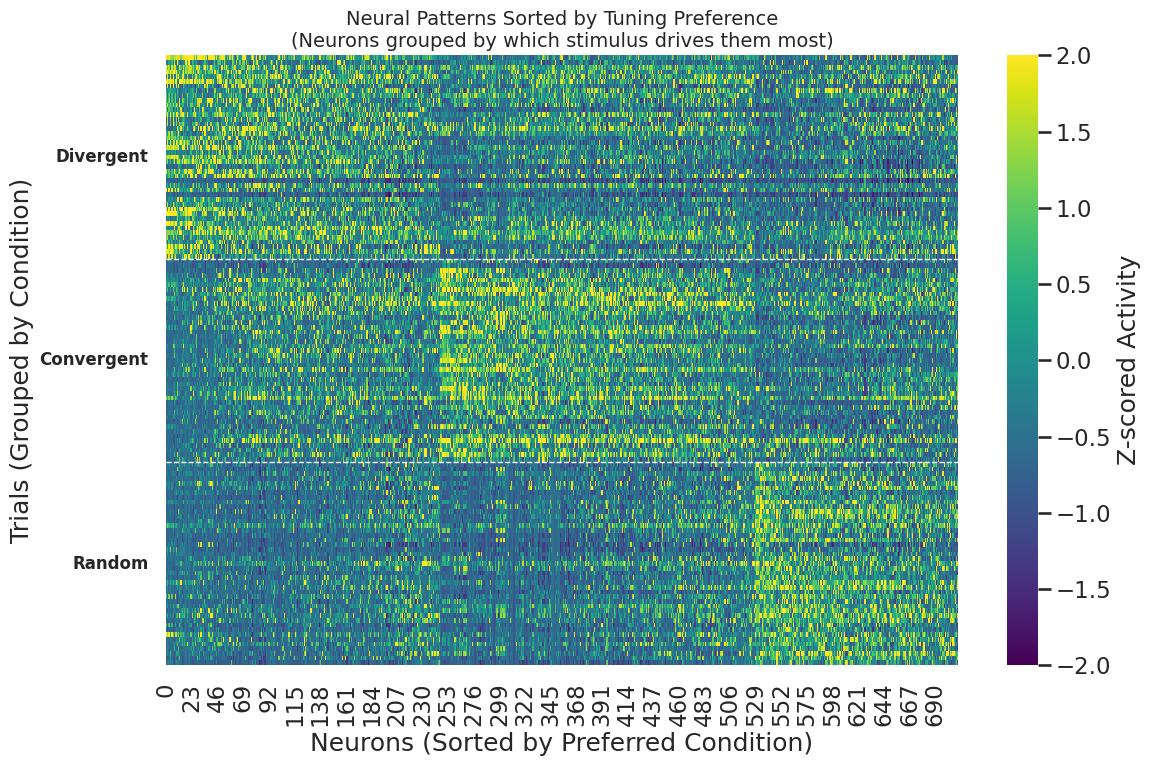

Generating Clustermap (Hierarchical Clustering)...


/beegfs_hdd/data/nfs_share/users/guiyun/nishome/brainnetwork/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


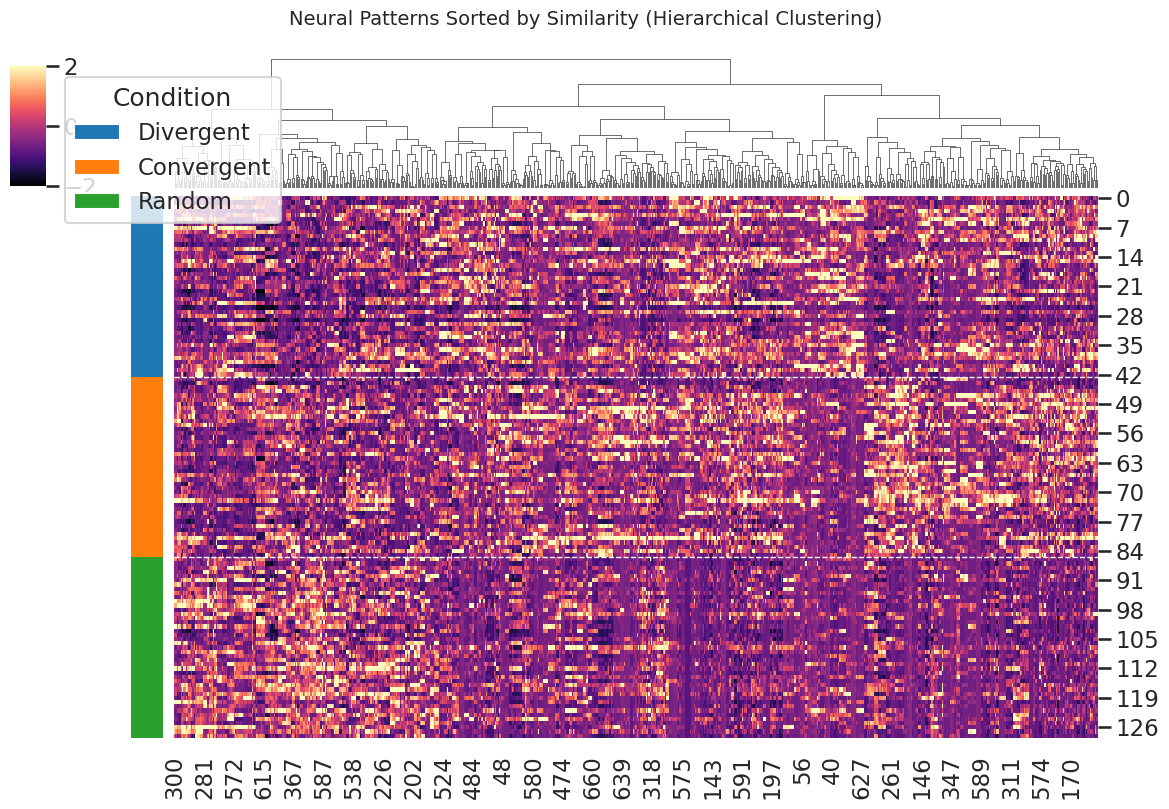

In [34]:
from scipy.stats import zscore

# 定义语义映射
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}
def plot_sorted_neural_patterns(X, labels, label_map):
    """
    可视化神经元活动热图，通过两种策略对神经元（X轴）进行排序，
    以揭示不同刺激条件（Y轴）下的Pattern差异。
    """
    
    # 1. 数据预处理
    # ------------------------------------------------
    # Z-score 归一化：消除神经元绝对发放率的差异，只看相对变化
    # axis=0 对每一列（神经元）做归一化
    X_norm = zscore(X, axis=0)
    
    # 替换 NaN (如果有些神经元完全不发放，std为0，zscore会产生nan)
    X_norm = np.nan_to_num(X_norm)
    
    unique_labels = np.unique(labels)
    sorted_labels = sorted(unique_labels) # 确保顺序: Divergent, Convergent, Random...
    
    # 获取标签的分界线位置，用于画横线
    label_counts = [np.sum(labels == l) for l in sorted_labels]
    boundaries = np.cumsum(label_counts)[:-1]
    
    # 重新排列 X 的行（Trial），确保它是按 Label 顺序排列的
    # (虽然通常已经是排好的，但为了保险起见)
    trial_sort_idx = np.argsort(labels)
    X_sorted_trials = X_norm[trial_sort_idx]
    labels_sorted = labels[trial_sort_idx]
    
    # ------------------------------------------------
    # 策略一：偏好性排序 (Preference Sorting)
    # ------------------------------------------------
    # 计算每个神经元在各条件下的平均活动
    n_neurons = X.shape[1]
    neuron_means = np.zeros((len(unique_labels), n_neurons))
    
    for i, l in enumerate(sorted_labels):
        # 找到该条件下的所有行
        mask = (labels == l)
        # 计算该条件下每个神经元的均值
        neuron_means[i, :] = np.mean(X_norm[mask], axis=0)
        
    # 找出每个神经元在哪个条件下最强 (Argmax)
    peak_condition_idx = np.argmax(neuron_means, axis=0)
    
    # 在同一个条件下，再按强度排个序，为了视觉更好看
    peak_magnitude = np.max(neuron_means, axis=0)
    
    # 综合排序键值: 先按条件ID排，再按强度排
    # 技巧: use lexsort. Primary key is last argument.
    sort_key = np.lexsort((-peak_magnitude, peak_condition_idx))
    
    X_pref_sorted = X_sorted_trials[:, sort_key]
    
    # ------------------------------------------------
    # 绘图 1: 偏好性排序热图
    # ------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(X_pref_sorted, ax=ax, cmap='viridis', vmin=-2, vmax=2, cbar_kws={'label': 'Z-scored Activity'})
    
    # 画水平线分隔不同条件
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='white', linestyles='--', linewidth=1)
        
    # 标注 Y 轴
    # 计算每个 Block 的中心位置
    y_centers = []
    current = 0
    for count in label_counts:
        y_centers.append(current + count/2)
        current += count
        
    ax.set_yticks(y_centers)
    ax.set_yticklabels([label_map[l] for l in sorted_labels], rotation=0, fontsize=12, fontweight='bold')
    
    ax.set_title("Neural Patterns Sorted by Tuning Preference\n(Neurons grouped by which stimulus drives them most)", fontsize=14)
    ax.set_xlabel("Neurons (Sorted by Preferred Condition)")
    ax.set_ylabel("Trials (Grouped by Condition)")
    
    plt.tight_layout()
    save_path = os.path.join(fig_out_dir, "neural_patterns_preference_sorted.png")
    fig.savefig(save_path, dpi=300)
    plt.show()

    # ------------------------------------------------
    # 策略二：层次聚类 (Hierarchical Clustering)
    # ------------------------------------------------
    # 这会展示神经元的自然功能团
    print("Generating Clustermap (Hierarchical Clustering)...")
    
    # 创建行颜色条
    label_colors = {l: sns.color_palette("tab10")[i] for i, l in enumerate(unique_labels)}
    row_colors = [label_colors[l] for l in labels_sorted]
    
    g = sns.clustermap(X_sorted_trials, 
                       method='ward', # 聚类算法
                       metric='euclidean',
                       col_cluster=True, # 对神经元聚类
                       row_cluster=False, # 不对 Trial 聚类 (保持条件顺序)
                       row_colors=row_colors,
                       cmap='magma', vmin=-2, vmax=2,
                       figsize=(12, 8),
                       dendrogram_ratio=(0.1, 0.2),
                       cbar_pos=(0.02, 0.8, 0.03, 0.15))
    
    # 添加水平线
    for b in boundaries:
        g.ax_heatmap.hlines(b, *g.ax_heatmap.get_xlim(), colors='white', linestyles='--', linewidth=1)
        
    g.fig.suptitle("Neural Patterns Sorted by Similarity (Hierarchical Clustering)", y=1.02, fontsize=14)
    
    # 手动添加 Legend
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=label_colors[l], label=label_map[l]) for l in sorted_labels]
    plt.legend(handles=handles, title='Condition', bbox_to_anchor=(1.2, 1), loc='upper left')
    save_path = os.path.join(fig_out_dir, "neural_patterns_clustermap.png")
    g.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# 运行代码
# 确保 X_trial_averaged_balanced 是 (n_trials, n_neurons)
plot_sorted_neural_patterns(X_trial_averaged_balanced, labels_balanced, label_names)

Stimulus        | Entropy (Bits)  | Mean Similarity | Std Similarity 
----------------------------------------------------------------------
Divergent       | 3.7258           | 0.4816          | 0.1419
Convergent      | 3.3083           | 0.5529          | 0.0961
Random          | 3.5266           | 0.5700          | 0.1154


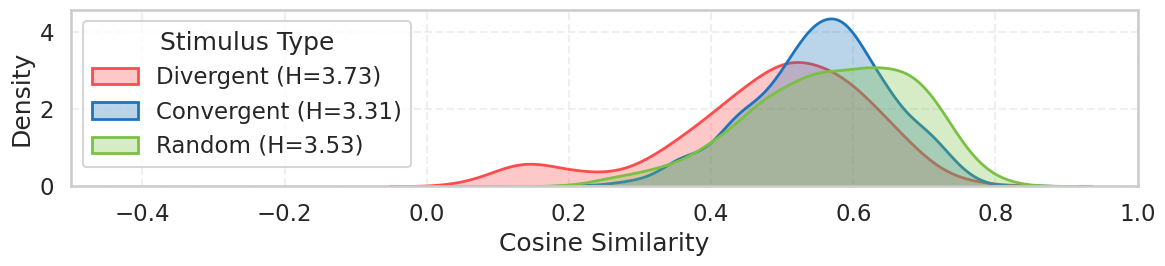

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy

def analyze_rsm_and_entropy(X, labels, label_map, n_bins=50):
    """
    计算不同刺激条件下的RSM熵值和相似度分布
    """
    results = []
    rsm_dict = {}
    similarity_values_dict = {}

    print(f"{'Stimulus':<15} | {'Entropy (Bits)':<15} | {'Mean Similarity':<15} | {'Std Similarity':<15}")
    print("-" * 70)

    # 遍历每种刺激标签
    unique_labels = np.unique(labels)
    for label in unique_labels:
        name = label_map[label]
        
        # 1. 提取该条件下的数据
        mask = (labels == label)
        X_sub = X[mask]
        
        # 2. 计算 RSM (Cosine Similarity)
        # 结果是 (n_trials, n_trials) 的矩阵，范围 [-1, 1]
        rsm = cosine_similarity(X_sub)
        rsm_dict[name] = rsm
        
        # 3. 提取上三角非对角线元素 (Off-diagonal upper triangle)
        # k=1 表示不包含对角线。因为我们只关心试次间的变异，不关心试次和自己的相似度
        triu_indices = np.triu_indices_from(rsm, k=1)
        sim_values = rsm[triu_indices]
        similarity_values_dict[name] = sim_values
        
        # 4. 计算香农熵 (Shannon Entropy)
        # 先将连续的相似度值通过直方图转为概率分布
        # range=(-1, 1) 覆盖余弦相似度的理论范围
        counts, _ = np.histogram(sim_values, bins=n_bins, range=(-1, 1), density=True)
        
        # 归一化为概率 (加上极小值防止 log(0) 错误)
        probs = counts / np.sum(counts)
        ent = entropy(probs, base=2)  # base=2 单位为 bits
        
        # 记录统计量
        results.append({
            'Stimulus': name,
            'Entropy': ent,
            'Mean_Sim': np.mean(sim_values),
            'Std_Sim': np.std(sim_values)
        })
        
        print(f"{name:<15} | {ent:.4f}           | {np.mean(sim_values):.4f}          | {np.std(sim_values):.4f}")

    return pd.DataFrame(results), rsm_dict, similarity_values_dict


df_entropy, rsm_data, sim_values_data = analyze_rsm_and_entropy(
    X_trial_averaged_balanced, 
    labels_balanced, 
    label_names,
    n_bins=50 # 分箱数，可以根据数据量调整，通常 30-100 之间
)

# --- 可视化 1: 相似度分布直方图 (验证是否"变平"了) ---
plt.figure(figsize=(12, 3))
colors = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143', 'Resting': '#111111'}

for name, values in sim_values_data.items():
    sns.kdeplot(values, label=f"{name} (H={df_entropy[df_entropy['Stimulus']==name]['Entropy'].values[0]:.2f})", 
                color=colors[name], fill=True, alpha=0.3, linewidth=2)

# plt.title("Distribution of Pairwise Cosine Similarities (RSM Off-diagonal)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.xlim(-0.5, 1.0) # 根据实际数据范围调整
plt.legend(title="Stimulus Type")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
save_path = os.path.join(fig_out_dir, "similarity_distribution.png")
plt.savefig(save_path, dpi=300)
plt.show()



In [36]:
# Experiment configuration
t_stimulus = 10
l_stimulus = 20
reliability_threshold = 0.75
snr_threshold = 0.8

def rr_selection_class(trials, labels, t_stimulus=t_stimulus, l_stimulus=l_stimulus, 
                 alpha_fdr=0.05, alpha_level=0.05, 
                 reliability_threshold=reliability_threshold, snr_threshold=snr_threshold, 
                 effect_size_threshold=0.5, response_ratio_threshold=0.8, 
                 max_n=2000):
    """
    快速RR神经元筛选 (按类分别计算后取并集)
    
    逻辑变更:
    1. 遍历 Label 1, 2, 3。
    2. 在每个 Label 内部计算响应性(Effect Size)和可靠性(SNR)。
    3. 筛选出该 Label 下的 RR 神经元。
    4. 将所有 Label 筛选出的神经元取并集 (Union)。
    """
    print("使用快速RR筛选算法 (按类分别筛选取并集)...")

    n_trials_total, n_neurons, n_timepoints = trials.shape
    
    # 定义时间窗口
    baseline_pre = np.arange(0, t_stimulus)
    baseline_post = np.arange(t_stimulus + l_stimulus, n_timepoints)
    stimulus_window = np.arange(t_stimulus, t_stimulus + l_stimulus)
    
    # 用于存储最终选中的神经元索引（使用集合自动去重，实现并集逻辑）
    rr_neurons = {}
    
    # 指定需要分析的类别
    target_classes = [1, 2, 3]
    
    for target_class in target_classes:
        # 1. 提取当前类别的试次
        class_mask = (labels == target_class)
        class_trials = trials[class_mask]
        
        n_class_trials = class_trials.shape[0]
        
        if n_class_trials == 0:
            print(f"警告: 类别 {target_class} 没有对应的试次，跳过。")
            continue
            
        # print(f"正在处理类别 {target_class}: {n_class_trials} 个试次")
        
        # 2. 响应性检测 - 向量化计算 (针对当前类别)
        
        # 计算基线 (Pre + Post)
        # mean (trials, neurons)
        cls_baseline_pre_mean = np.mean(class_trials[:, :, baseline_pre], axis=2)
        cls_baseline_post_mean = np.mean(class_trials[:, :, baseline_post], axis=2)
        cls_baseline_mean = (cls_baseline_pre_mean + cls_baseline_post_mean) / 2
        
        # std (trials, neurons)
        cls_baseline_pre_std = np.std(class_trials[:, :, baseline_pre], axis=2)
        cls_baseline_post_std = np.std(class_trials[:, :, baseline_post], axis=2)
        cls_baseline_std = (cls_baseline_pre_std + cls_baseline_post_std) / 2
        
        # 计算刺激期
        cls_stimulus_mean = np.mean(class_trials[:, :, stimulus_window], axis=2)
        cls_stimulus_std = np.std(class_trials[:, :, stimulus_window], axis=2)
        
        # 计算 Cohen's d 效应大小
        # pooled_std
        cls_pooled_std = np.sqrt((cls_baseline_std**2 + cls_stimulus_std**2) / 2)
        cls_effect_size = np.abs(cls_stimulus_mean - cls_baseline_mean) / (cls_pooled_std + 1e-8)
        
        # 筛选1：响应性 (Enhanced)
        # 标准：平均效应大小 > 阈值 且 刺激均值 > 基线均值 (兴奋性)
        cls_response_ratio = np.mean(cls_effect_size > effect_size_threshold, axis=0)
        
        # 注意：这里保持你的逻辑，既要 response_ratio 达标，又要总体均值是增强的(兴奋性)
        is_enhanced_mean = np.mean(cls_stimulus_mean > cls_baseline_mean, axis=0) > response_ratio_threshold
        is_responsive = (cls_response_ratio > response_ratio_threshold) & is_enhanced_mean
        
        class_enhanced_indices = np.where(is_responsive)[0]

        # 3. 可靠性检测 (Reliability)
        
        # 信噪比 SNR
        cls_signal_strength = np.abs(cls_stimulus_mean - cls_baseline_mean)
        cls_noise_level = cls_baseline_std + 1e-8
        cls_snr = cls_signal_strength / cls_noise_level
        
        # 筛选2：可靠性
        cls_reliability_ratio = np.mean(cls_snr > snr_threshold, axis=0)
        class_reliable_indices = np.where(cls_reliability_ratio >= reliability_threshold)[0]
        
        # 4. 取当前类别的交集 (既响应又可靠)
        # intersect1d 用于取两个数组的交集
        class_rr_indices = np.intersect1d(class_enhanced_indices, class_reliable_indices)
        
        # 5. 加入到总集合中 (Union 操作)
        rr_neurons[target_class] = set(class_rr_indices)
        
        print(f"  - 类别 {target_class} 贡献了 {len(class_rr_indices)} 个 RR 神经元")
    
    return rr_neurons

rr_neurons_spi = rr_selection_class(segments_spi, labels_spi)
rr_neurons_flo = rr_selection_class(segments_flo, labels_flo)

使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 376 个 RR 神经元
  - 类别 2 贡献了 364 个 RR 神经元
  - 类别 3 贡献了 345 个 RR 神经元
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 686 个 RR 神经元
  - 类别 2 贡献了 798 个 RR 神经元
  - 类别 3 贡献了 671 个 RR 神经元


In [37]:
# --- 2.1 提取网络拓扑指标 (Network Metrics) [cite: 350, 506-518] ---
import json
import pandas as pd
mouse_id = data_paths[idx]
print(f"提取网络指标并保存为 CSV 和 Markdown 格式... {mouse_id}")
metrics_md_table = "网络数据未生成"
if 'nx_result' in locals():
    metrics_list = []
    for cls, res in nx_result.items():
        row = {'Class_ID': cls}
        if 'summary' in res:
            row.update(res['summary'])
        if 'efficiency' in res: row['efficiency'] = res['efficiency']
        if 'modularity' in res: row['modularity'] = res['modularity']
        if 'betweenness_stats' in res: row['betweenness_mean'] = res['betweenness_stats'].get('mean', np.nan)
        metrics_list.append(row)
    
    df_metrics = pd.DataFrame(metrics_list)
    metrics_csv_path = os.path.join(data_out_dir, f"{mouse_id}_network_metrics.csv")
    df_metrics.to_csv(metrics_csv_path, index=False)
    metrics_md_table = df_metrics.round(4).to_markdown(index=False) # 格式化为 MD 表格备用

# --- 2.2 提取随时间变化的解码准确率 [cite: 325-326] ---
if 'accuracies' in locals() and 'time_points' in locals():
    df_acc = pd.DataFrame({
        'Time(s)': time_points,
        'Accuracy': accuracies,
        'Baseline': accuracies_shu if 'accuracies_shu' in locals() else np.nan,
        'Accuracy_STD': accuracy_std if 'accuracy_std' in locals() else np.nan
    })
    acc_csv_path = os.path.join(data_out_dir, f"{mouse_id}_decoding_accuracy.csv")
    df_acc.to_csv(acc_csv_path, index=False)

# --- 2.3 提取 RR 神经元索引集合 [cite: 908-909] ---
import json
import numpy as np
import datetime

# --- 2.3 提取 RR 神经元索引集合 ---
class NumpyEncoder(json.JSONEncoder):
    """自定义 JSON 编码器，用于处理 NumPy 数据类型和 Set 集合"""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, set):
            return list(obj)
        return super(NumpyEncoder, self).default(obj)

rr_data_dict = {}
if 'rr_neurons_spi' in locals(): 
    rr_data_dict['spike'] = rr_neurons_spi
if 'rr_neurons_flo' in locals(): 
    rr_data_dict['fluorescence'] = rr_neurons_flo

rr_json_path = os.path.join(data_out_dir, f"{mouse_id}_rr_neurons_indices.json")
with open(rr_json_path, 'w', encoding='utf-8') as f:
    # 传入 cls=NumpyEncoder 接管默认的序列化过程
    json.dump(rr_data_dict, f, indent=4, cls=NumpyEncoder)

# 3. 整合 Markdown 自动化报告
md_file_path = os.path.join(save_dir, f"{mouse_id}_comprehensive_report.md")
current_time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

md_content = f"""# 小鼠 {mouse_id} 综合数据分析报告

## 1. 基础元数据
- **原始数据源**: `{data_path}`
- **分析生成时间**: `{current_time}`
- **数据导出目录**: `[{save_dir}/data/](./data/)` (包含CSV与JSON)
- **图表导出目录**: `[{save_dir}/figures/](./figures/)`

---

## 2. 关键结果数据表

### 2.1 网络拓扑核心指标 (Network Metrics)
以下为不同刺激条件下的图论特征统计（详见 `[data/{mouse_id}_network_metrics.csv](./data/{mouse_id}_network_metrics.csv)`）：

{metrics_md_table}

### 2.2 RR 神经元与解码数据
* **RR 神经元索引**: 已将不同类别的响应神经元原位索引导出至 `[JSON文件]({save_dir}/data/{mouse_id}_rr_neurons_indices.json)`，可用于后续特征追踪。
* **时间窗解码准确率**: 各时间点的分类表现及打乱基线数据已导出至 `[CSV文件]({save_dir}/data/{mouse_id}_decoding_accuracy.csv)`。

---

## 3. 核心可视化图表
*(注：以下图片链接指向本地 `./figures/` 目录。必须在上方对应的绘图函数中添加 `fig.savefig()` 以生成这些文件)*

### 3.1 RR 神经元空间分布
![RR Distribution](../{fig_out_dir}/rr_distribution.png)

### 3.2 群体平均响应时间序列 (Population Average)
![Population Avg](../{fig_out_dir}/rr_population_average.png)

### 3.3 动态分类准确率 (Decoding Accuracy)
![Decoding Accuracy](../{fig_out_dir}/classification_accuracy.png)

{accuracies if 'accuracies' in locals() else "解码准确率数据未生成"}
{accuracy_std if 'accuracy_std' in locals() else "解码准确率标准差数据未生成"}

### 3.4 神经元活动响应聚类 (Clustermap)
![Clustermap](../{fig_out_dir}/neural_patterns_clustermap.png)
![Preference Sorted](../{fig_out_dir}/neural_patterns_preference_sorted.png)
![Similarity Distribution](../{fig_out_dir}/similarity_distribution.png)   

### 3.5 变量相关性与网络指标提琴图 (Violin/Bars)

![Correlation Violin](../{fig_out_dir}/correlation_violin.png)
![Network Metrics Bars](../{fig_out_dir}/network_metrics_bars.png)
""" 

# 4. 写入 Markdown 并输出状态
with open(md_file_path, "w", encoding="utf-8") as f:
    f.write(md_content)

print(f"✅ 执行完毕。")
print(f" - 数据文件已保存至: {os.path.abspath(data_out_dir)}")
print(f" - 综合报告已生成: {os.path.abspath(md_file_path)}")

提取网络指标并保存为 CSV 和 Markdown 格式... M77_1031
✅ 执行完毕。
 - 数据文件已保存至: /beegfs_hdd/data/nfs_share/users/guiyun/nishome/brainnetwork/results/M77_1031/data
 - 综合报告已生成: /beegfs_hdd/data/nfs_share/users/guiyun/nishome/brainnetwork/results/M77_1031/M77_1031_comprehensive_report.md


使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 376 个 RR 神经元
  - 类别 2 贡献了 364 个 RR 神经元
  - 类别 3 贡献了 345 个 RR 神经元
三类并集后共筛选出 711 个唯一 RR 神经元
All neurons: 35896
RR neurons: 711
non-RR neurons: 35185


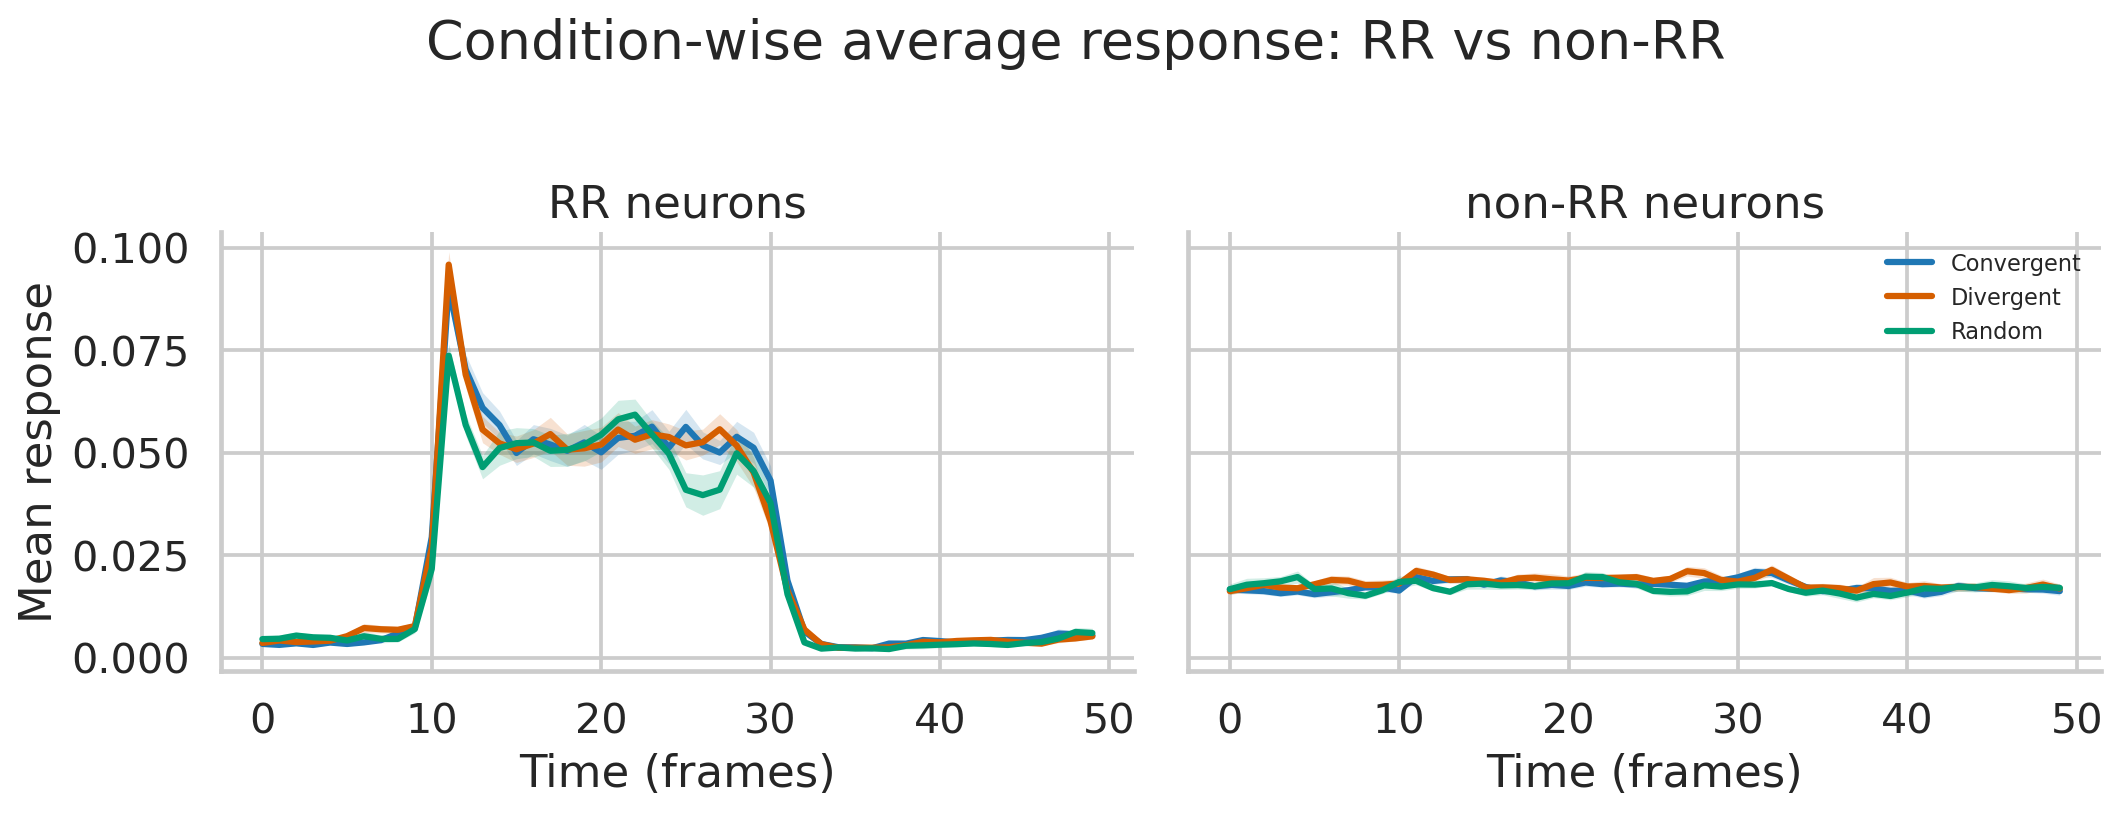

In [38]:
# RR vs non-RR response comparison (added by Codex)
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from brainnetwork import preprocess_spike_data, rr_selection

# Rebuild all-neuron trial segments from the same loaded data
segments_all, labels_all, _ = preprocess_spike_data(
    neuron_data,
    neuron_pos,
    start_edges,
    stimulus_data,
    extract_rr=False,
)
labels_all = np.asarray(labels_all)

# RR / non-RR split
rr_idx = np.asarray(rr_selection(segments_all, labels_all), dtype=int)
all_idx = np.arange(segments_all.shape[1])
non_rr_idx = np.setdiff1d(all_idx, rr_idx)

if non_rr_idx.size == 0:
    raise ValueError("No non-RR neurons found. Please check RR selection settings.")

print(f"All neurons: {segments_all.shape[1]}")
print(f"RR neurons: {rr_idx.size}")
print(f"non-RR neurons: {non_rr_idx.size}")

segments_rr = segments_all[:, rr_idx, :]
segments_nonrr = segments_all[:, non_rr_idx, :]
class_ids = sorted(np.unique(labels_all).tolist())

CLASS_NAMES = {1: "Convergent", 2: "Divergent", 3: "Random"}
CLASS_COLORS = {1: "#1F77B4", 2: "#D55E00", 3: "#009E73"}

def class_curve_and_sem(segments_group, labels, cls):
    cls_segments = segments_group[labels == cls]
    pop_mean = np.nanmean(cls_segments, axis=(0, 1))
    trial_means = np.nanmean(cls_segments, axis=1)
    pop_sem = stats.sem(trial_means, axis=0, nan_policy="omit")
    return pop_mean, pop_sem

time_axis = np.arange(segments_all.shape[2])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=180, sharex=True, sharey=True)

for ax, seg_group, title in [
    (axes[0], segments_rr, "RR neurons"),
    (axes[1], segments_nonrr, "non-RR neurons"),
]:
    for cls in class_ids:
        if cls not in CLASS_COLORS:
            continue
        m, se = class_curve_and_sem(seg_group, labels_all, cls)
        c = CLASS_COLORS[cls]
        ax.plot(time_axis, m, color=c, lw=2.5, label=CLASS_NAMES.get(cls, f"Class {cls}"))
        ax.fill_between(time_axis, m - se, m + se, color=c, alpha=0.18, linewidth=0)

    ax.set_title(title)
    ax.set_xlabel("Time (frames)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Mean response")
axes[1].legend(frameon=False, fontsize=9)
fig.suptitle("Condition-wise average response: RR vs non-RR", y=1.02)
fig.tight_layout()
plt.show()



RR union size: 711
Class 1 RR size: 376
Class 2 RR size: 364
Class 3 RR size: 345


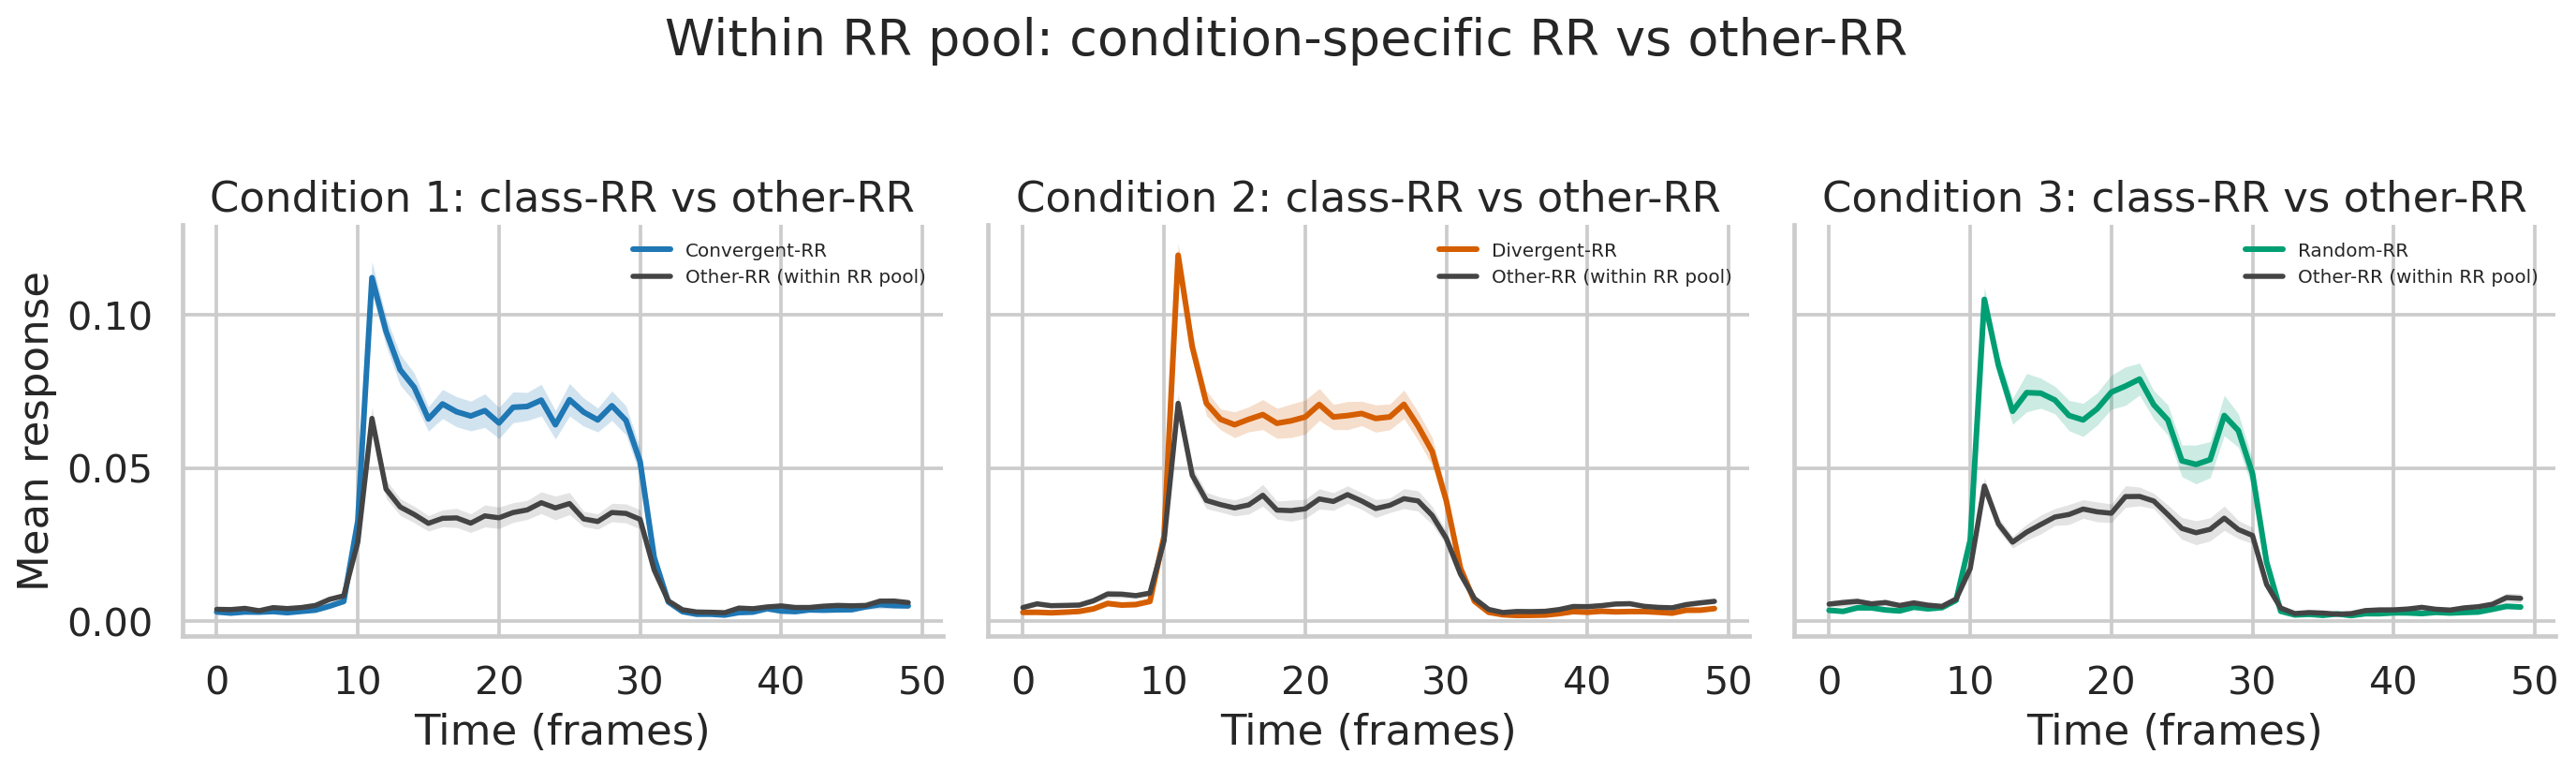

In [39]:
# Condition-specific RR vs other-RR within RR pool (added by Codex)
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from brainnetwork import preprocess_spike_data

# Rebuild all-neuron segments (no RR filtering)
segments_all, labels_all, _ = preprocess_spike_data(
    neuron_data,
    neuron_pos,
    start_edges,
    stimulus_data,
    extract_rr=False,
)
labels_all = np.asarray(labels_all)

# Hyperparameters aligned with rr_selection defaults in loaddata.py
t_stimulus_local = 10
l_stimulus_local = 20
effect_size_threshold = 0.5
response_ratio_threshold = 0.8
snr_threshold_local = 0.8
reliability_threshold_local = 0.75

baseline_pre = np.arange(0, t_stimulus_local)
baseline_post = np.arange(t_stimulus_local + l_stimulus_local, segments_all.shape[2])
stim_window = np.arange(t_stimulus_local, t_stimulus_local + l_stimulus_local)

def rr_indices_for_class(trials_cls):
    # trials_cls: (n_trials_cls, n_neurons, n_time)
    b_pre_mean = np.mean(trials_cls[:, :, baseline_pre], axis=2)
    b_post_mean = np.mean(trials_cls[:, :, baseline_post], axis=2)
    baseline_mean = 0.5 * (b_pre_mean + b_post_mean)

    b_pre_std = np.std(trials_cls[:, :, baseline_pre], axis=2)
    b_post_std = np.std(trials_cls[:, :, baseline_post], axis=2)
    baseline_std = 0.5 * (b_pre_std + b_post_std)

    stim_mean = np.mean(trials_cls[:, :, stim_window], axis=2)
    stim_std = np.std(trials_cls[:, :, stim_window], axis=2)

    pooled_std = np.sqrt((baseline_std**2 + stim_std**2) / 2)
    effect_size = np.abs(stim_mean - baseline_mean) / (pooled_std + 1e-8)

    response_ratio = np.mean(effect_size > effect_size_threshold, axis=0)
    enhanced_mean = np.mean(stim_mean > baseline_mean, axis=0) > response_ratio_threshold
    enhanced_idx = np.where((response_ratio > response_ratio_threshold) & enhanced_mean)[0]

    snr = np.abs(stim_mean - baseline_mean) / (baseline_std + 1e-8)
    reliability_ratio = np.mean(snr > snr_threshold_local, axis=0)
    reliable_idx = np.where(reliability_ratio >= reliability_threshold_local)[0]

    return np.intersect1d(enhanced_idx, reliable_idx)

# Build class-specific RR sets on all neurons
class_ids = sorted(np.unique(labels_all).tolist())
rr_by_class = {}
for cls in class_ids:
    cls_trials = segments_all[labels_all == cls]
    rr_by_class[cls] = rr_indices_for_class(cls_trials)

# Union RR pool (same concept as global RR)
rr_union = np.array(sorted(set(np.concatenate([v for v in rr_by_class.values()]).tolist())), dtype=int)
print(f'RR union size: {rr_union.size}')
for cls in class_ids:
    print(f'Class {cls} RR size: {rr_by_class[cls].size}')

CLASS_NAMES = {1: 'Convergent', 2: 'Divergent', 3: 'Random'}
CLASS_COLORS = {1: '#1F77B4', 2: '#D55E00', 3: '#009E73'}

def pop_curve_and_sem(trials_subset):
    # trials_subset: (n_trials, n_neurons_subset, n_time)
    m = np.nanmean(trials_subset, axis=(0, 1))
    trial_means = np.nanmean(trials_subset, axis=1)  # (n_trials, n_time)
    se = stats.sem(trial_means, axis=0, nan_policy='omit')
    return m, se

# For each condition c:
# compare c-specific RR vs (RR union - c-specific RR), both evaluated under condition c trials
time_axis = np.arange(segments_all.shape[2])
fig, axes = plt.subplots(1, len(class_ids), figsize=(5.2 * len(class_ids), 4.5), dpi=180, sharey=True)
if len(class_ids) == 1:
    axes = [axes]

for ax, cls in zip(axes, class_ids):
    cls_trials = segments_all[labels_all == cls]
    rr_cls = rr_by_class[cls]
    other_rr = np.setdiff1d(rr_union, rr_cls)

    if rr_cls.size == 0:
        ax.set_title(f'Class {cls}: no class-specific RR')
        ax.axis('off')
        continue

    m_rr, se_rr = pop_curve_and_sem(cls_trials[:, rr_cls, :])
    ax.plot(time_axis, m_rr, color=CLASS_COLORS.get(cls, '#1F77B4'), lw=2.4, label=f'{CLASS_NAMES.get(cls, cls)}-RR')
    ax.fill_between(time_axis, m_rr - se_rr, m_rr + se_rr, color=CLASS_COLORS.get(cls, '#1F77B4'), alpha=0.2, linewidth=0)

    if other_rr.size > 0:
        m_oth, se_oth = pop_curve_and_sem(cls_trials[:, other_rr, :])
        ax.plot(time_axis, m_oth, color='#444444', lw=2.2, label='Other-RR (within RR pool)')
        ax.fill_between(time_axis, m_oth - se_oth, m_oth + se_oth, color='#444444', alpha=0.15, linewidth=0)

    ax.set_title(f'Condition {cls}: class-RR vs other-RR')
    ax.set_xlabel('Time (frames)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel('Mean response')
fig.suptitle('Within RR pool: condition-specific RR vs other-RR', y=1.03)
fig.tight_layout()
plt.show()



## 1. RR数量、参与度、相关性与图论差异汇总分析

### 1.1 神经元数量以及编码能力
- 各个条件下 RR 神经元比例
- 总体编码准确率

### 1.2 神经元之间参与度与编码空间
- 当前条件 RR 神经元响应 vs 其他 RR 神经元响应的比值
- pattern vector 的余弦相似度

### 1.3 神经元之间的成对相关性
- 成对相关性强度及条件差异
- 强相关 vs 弱相关（按比例切分）

### 1.4 神经元图论差异
- 更完整的图指标表
- 热图与汇总图


Section 1 analysis for: M77_1031


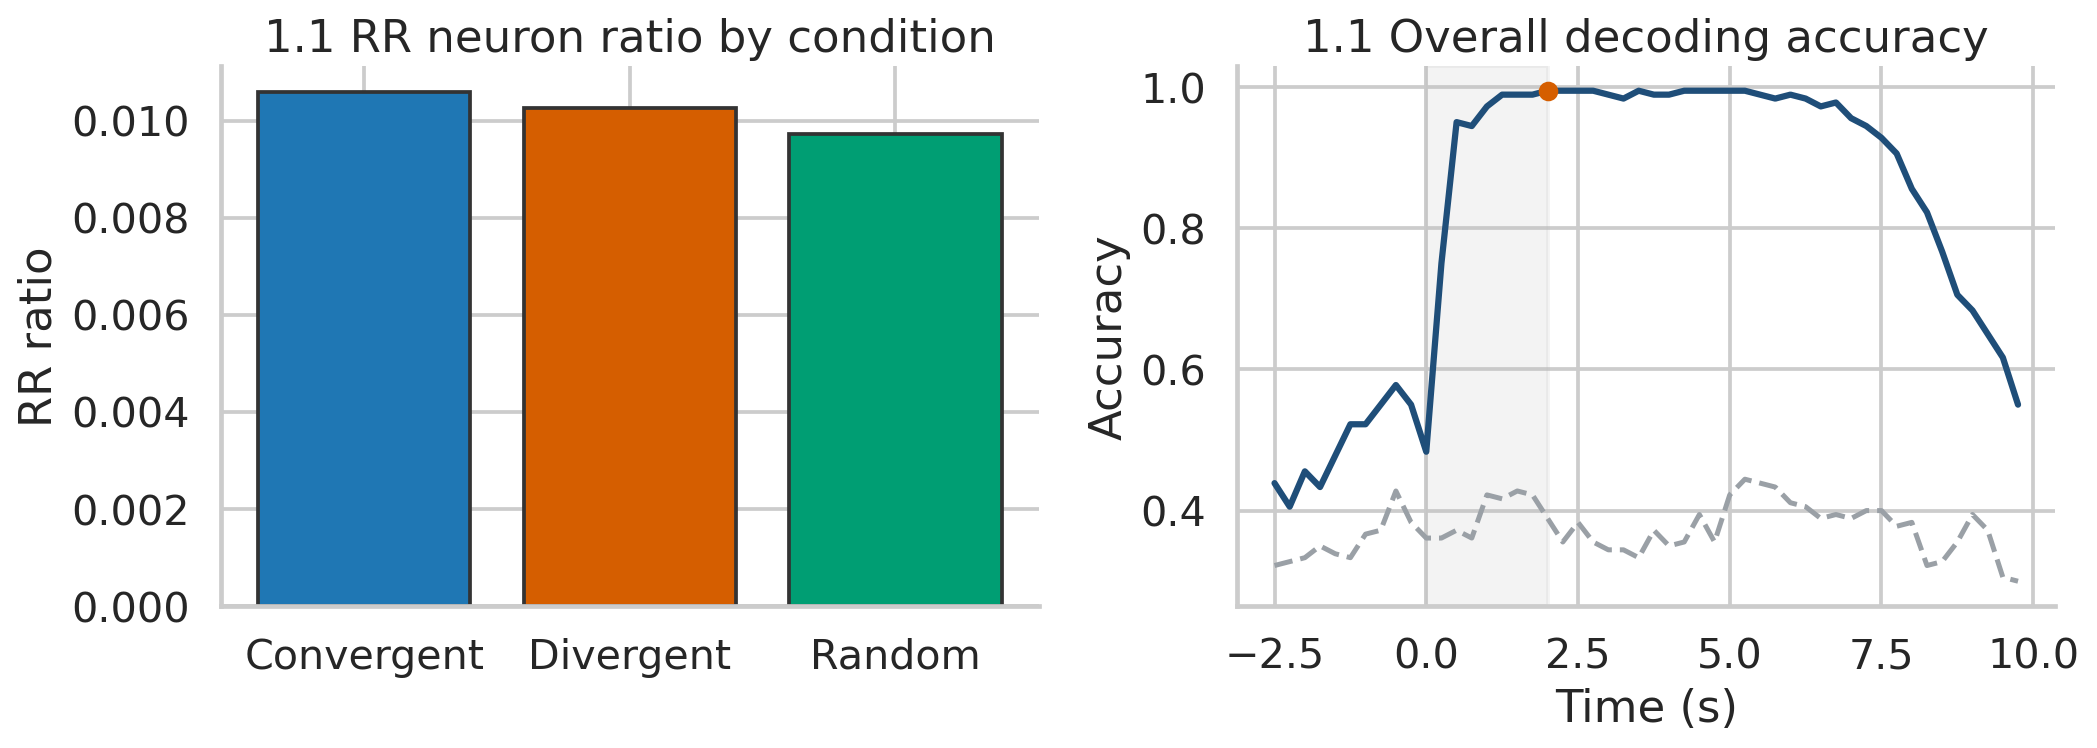

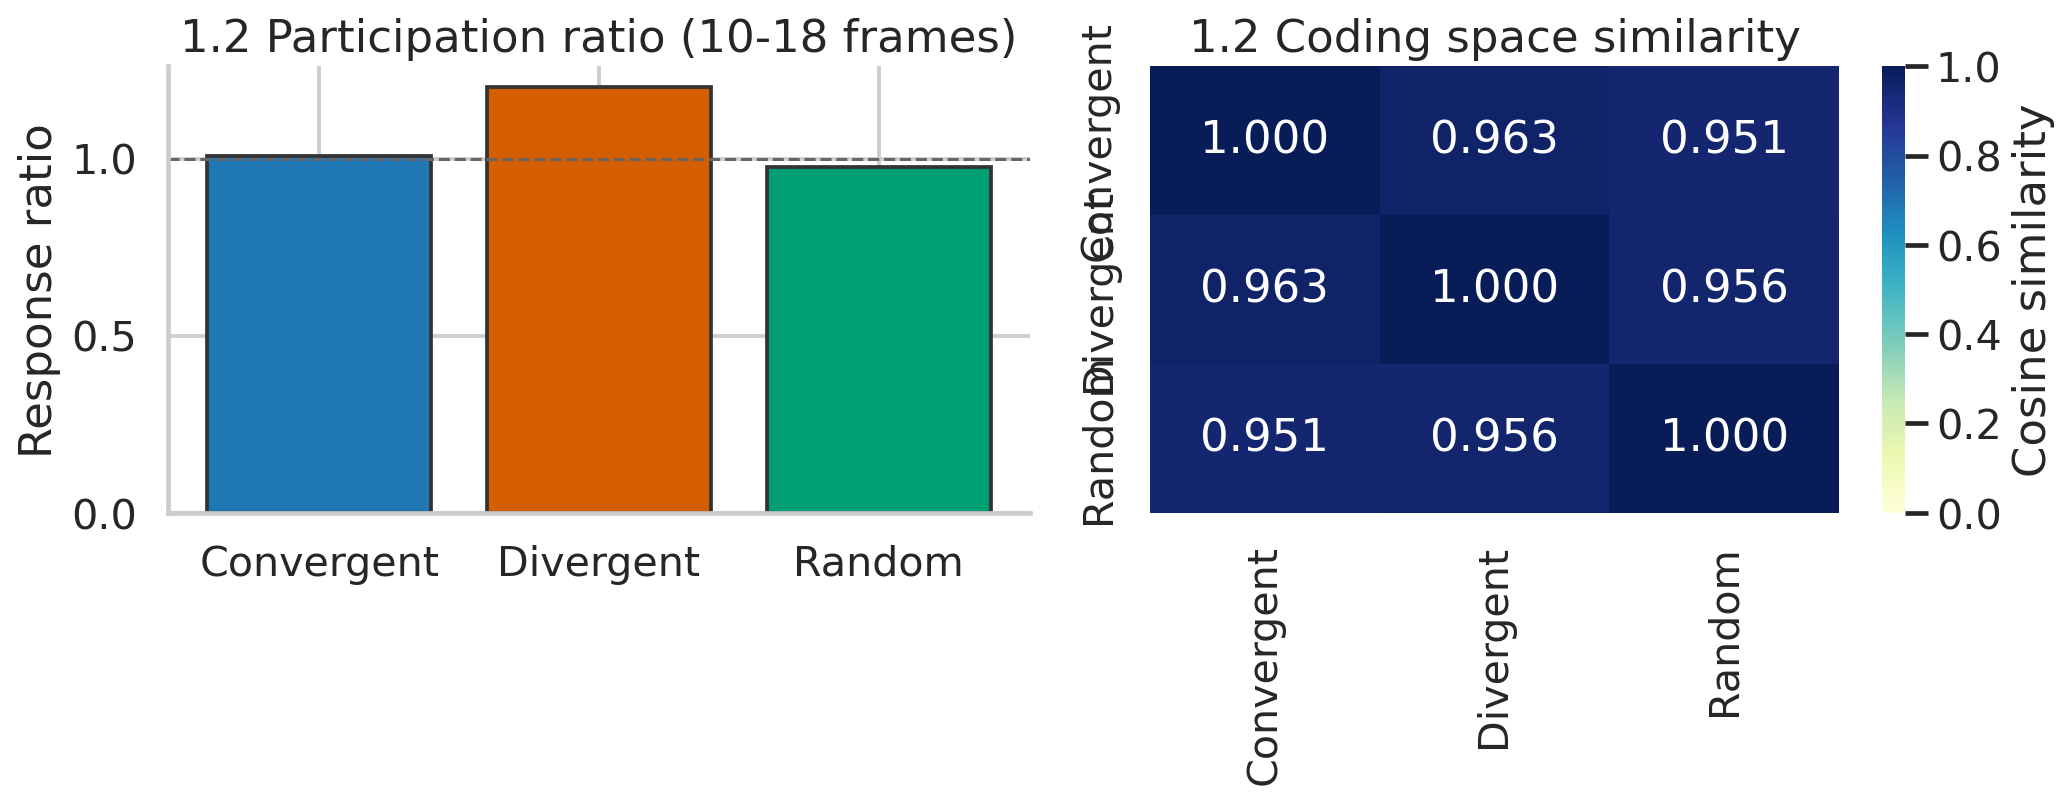

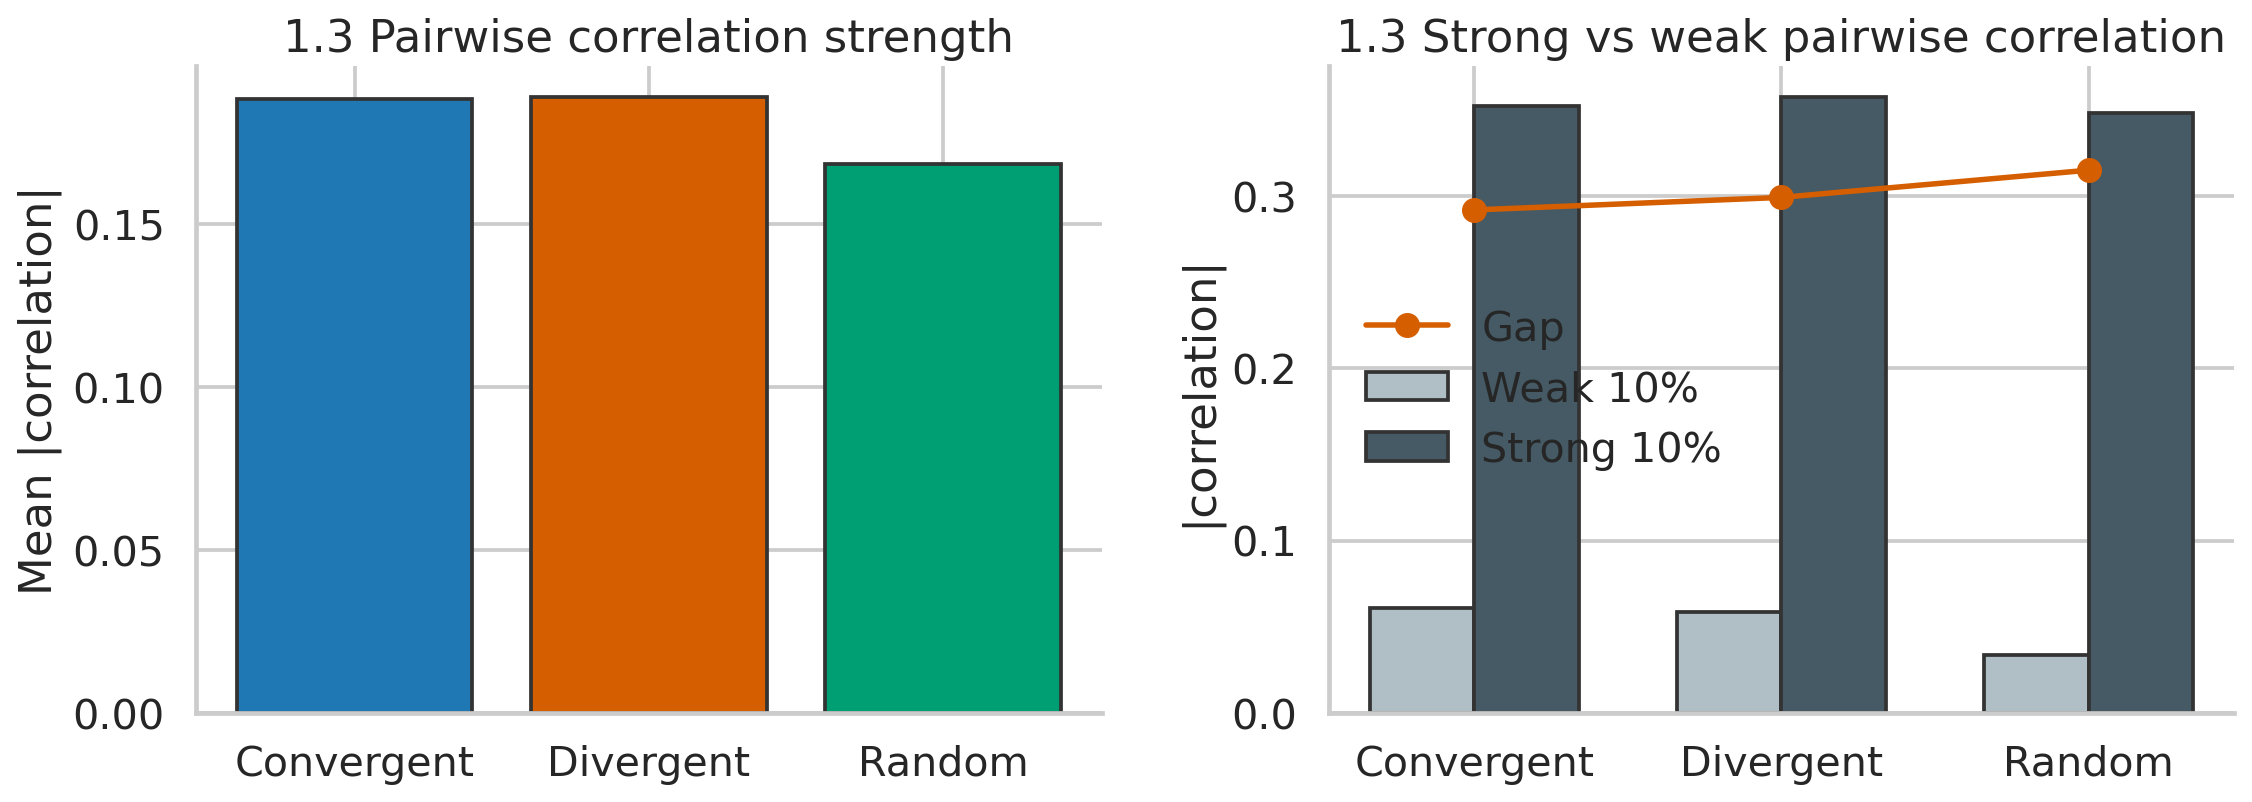

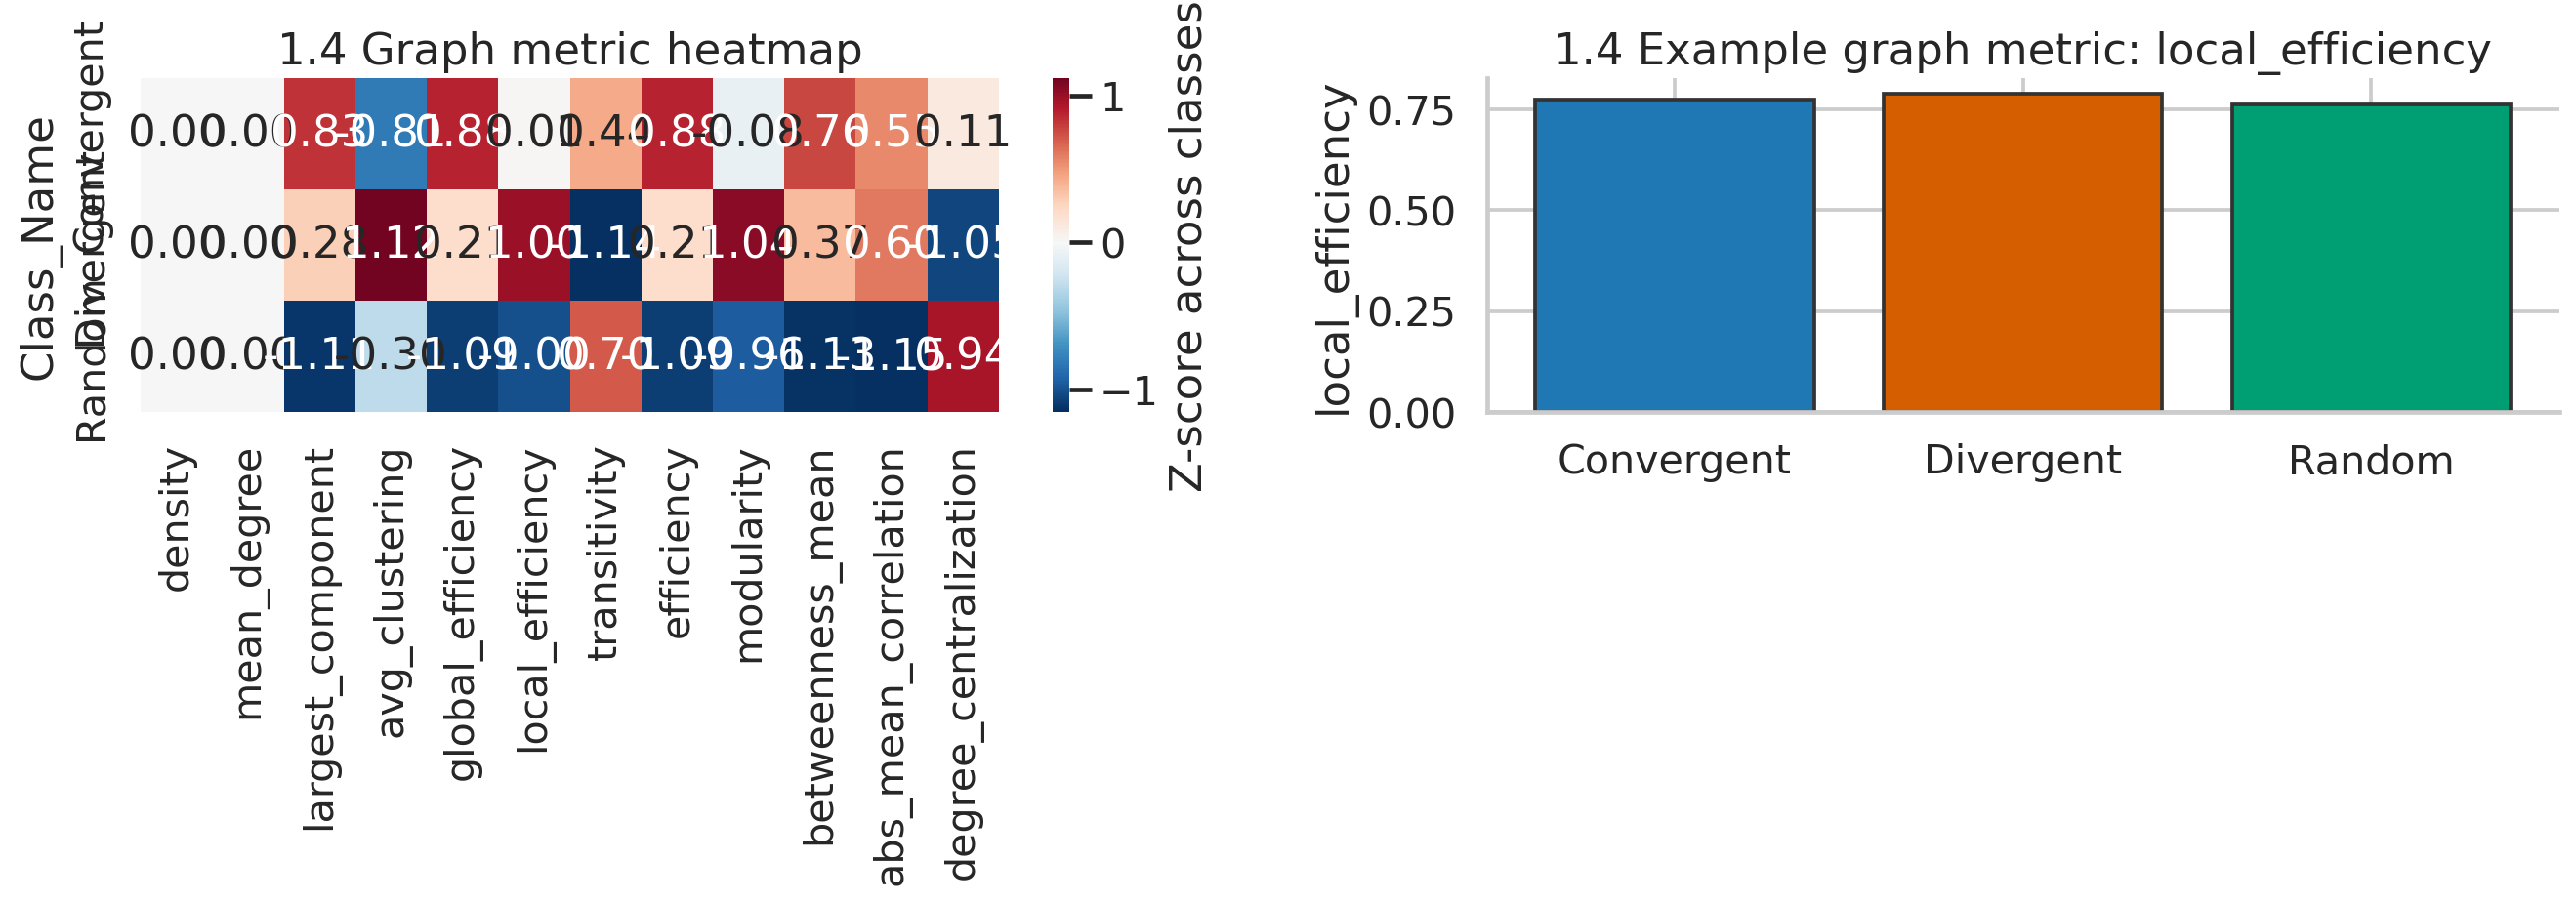

Saved files:
../results/M77_1031/data/M77_1031_section1_rr_ratio.csv
../results/M77_1031/data/M77_1031_section1_accuracy_summary.csv
../results/M77_1031/data/M77_1031_section1_participation.csv
../results/M77_1031/data/M77_1031_section1_cosine_similarity.csv
../results/M77_1031/data/M77_1031_section1_pairwise_correlation.csv
../results/M77_1031/data/M77_1031_section1_graph_metrics_extended.csv
../results/M77_1031/data/M77_1031_section1_summary.md


,Class_ID,Class_Name,Trial_Count,Total_Neurons,RR_Count,RR_Ratio
0,1,Convergent,81,35499,376,0.010592
1,2,Divergent,57,35499,364,0.010254
2,3,Random,42,35499,345,0.009719


,Metric,Value
0,mean_accuracy,0.823444
1,peak_accuracy,0.994444
2,peak_time,2.000000


,Class_ID,Class_Name,Current_RR_Count,Other_RR_Count,Current_RR_Response_10_18,Other_RR_Response_10_18,Response_Ratio_Current_vs_Other
0,1,Convergent,376,335,0.012736,0.012642,1.007467
1,2,Divergent,364,347,0.014605,0.012162,1.200850
2,3,Random,345,366,0.016045,0.016413,0.977592


,Convergent,Divergent,Random
Convergent,1.000000,0.962635,0.950848
Divergent,0.962635,1.000000,0.955975
Random,0.950848,0.955975,1.000000


,Class_ID,Class_Name,Mean_Correlation,Mean_Abs_Correlation,Weak_Abs_Correlation_Mean,Strong_Abs_Correlation_Mean,Strong_Weak_Gap,Pair_Count
0,1,Convergent,0.188369,0.188369,0.060580,0.352669,0.292088,252405
1,2,Divergent,0.188957,0.188957,0.058326,0.357702,0.299376,252405
2,3,Random,0.168247,0.168247,0.033476,0.348663,0.315187,252405


,Class_ID,Class_Name,n_nodes,n_edges,density,mean_degree,largest_component,avg_clustering,global_efficiency,local_efficiency,...,modularity,betweenness_mean,mean_correlation,abs_mean_correlation,positive_edge_fraction,negative_edge_fraction,degree_assortativity,avg_shortest_path_lcc,diameter_lcc,degree_centralization
0,1,Convergent,711,12620,0.049999,35.499297,648,0.631810,0.351475,0.774579,...,0.266894,0.001979,0.188369,0.188377,0.999418,0.000582,0.064487,2.689717,7.0,0.311440
1,2,Divergent,711,12620,0.049999,35.499297,635,0.661458,0.338071,0.786972,...,0.309141,0.001911,0.188957,0.189019,0.997714,0.002286,0.030220,2.698472,7.0,0.281780
2,3,Random,711,12620,0.049999,35.499297,602,0.639689,0.312004,0.761831,...,0.234082,0.001650,0.168247,0.168406,0.992401,0.007599,-0.007453,2.632031,7.0,0.332627


In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats
from IPython.display import display
from brainnetwork import preprocess_spike_data, compute_network_metrics_by_class

sns.set_theme(style="whitegrid", context="talk")

analysis_mouse_id = locals().get("mouse_id")
if analysis_mouse_id is None:
    if "data_path" in locals() and isinstance(data_path, str):
        analysis_mouse_id = os.path.basename(data_path.rstrip("/\\"))
    else:
        analysis_mouse_id = "single_mouse"

section_prefix = "section1"
os.makedirs(fig_out_dir, exist_ok=True)
os.makedirs(data_out_dir, exist_ok=True)

if "segments_all_spi" not in locals() or "labels_all_spi" not in locals():
    segments_all_spi, labels_all_spi, _ = preprocess_spike_data(
        neuron_data,
        neuron_pos,
        start_edges,
        stimulus_data,
        extract_rr=False,
    )
labels_all_spi = np.asarray(labels_all_spi)

if "rr_neurons_spi" not in locals():
    rr_neurons_spi = rr_selection_class(segments_all_spi, labels_all_spi)

if "nx_result" not in locals():
    nx_result = compute_network_metrics_by_class(segments_spi, labels_spi, neuron_pos_spi, do_bootstrap=False)

class_ids = sorted(np.unique(labels_all_spi).tolist())
class_names_local = {1: "Convergent", 2: "Divergent", 3: "Random"}
class_colors_local = {1: "#1F77B4", 2: "#D55E00", 3: "#009E73"}
frame_slice = slice(10, 13)
strong_frac = 0.10
weak_frac = 0.10


def sem_safe(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size <= 1:
        return np.nan
    return float(np.std(values, ddof=1) / np.sqrt(values.size))


def response_in_window(trials, neuron_idx, stim_slice=frame_slice):
    neuron_idx = np.asarray(sorted(neuron_idx), dtype=int)
    if neuron_idx.size == 0:
        return np.nan
    return float(np.mean(trials[:, neuron_idx, stim_slice]))


def pattern_vector(trials, neuron_idx, stim_slice=frame_slice):
    neuron_idx = np.asarray(sorted(neuron_idx), dtype=int)
    if neuron_idx.size == 0:
        return np.array([], dtype=float)
    return np.mean(trials[:, neuron_idx, stim_slice], axis=(0, 2))


def cosine_similarity_matrix(pattern_dict, ordered_classes):
    mat = np.vstack([pattern_dict[cls] for cls in ordered_classes])
    norms = np.linalg.norm(mat, axis=1, keepdims=True) + 1e-12
    mat_norm = mat / norms
    return mat_norm @ mat_norm.T


def upper_triangle_values(matrix):
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    return matrix[mask]


def summarize_graph_metrics(nx_payload):
    rows = []
    for cls in sorted(nx_payload):
        info = nx_payload[cls]
        graph = info["corr_graph"]
        corr = np.asarray(info["corr_matrix"], dtype=float)
        offdiag = upper_triangle_values(corr)

        if graph.number_of_nodes() > 0 and graph.number_of_edges() > 0:
            assort = nx.degree_assortativity_coefficient(graph)
            components = list(nx.connected_components(graph))
            largest_nodes = max(components, key=len)
            largest_subgraph = graph.subgraph(largest_nodes).copy()
            avg_path = nx.average_shortest_path_length(largest_subgraph) if largest_subgraph.number_of_nodes() > 1 else np.nan
            diameter = nx.diameter(largest_subgraph) if largest_subgraph.number_of_nodes() > 1 else np.nan
            degrees = np.array([deg for _, deg in graph.degree()], dtype=float)
            if graph.number_of_nodes() > 2:
                centralization = (degrees.max() - degrees).sum() / ((graph.number_of_nodes() - 1) * (graph.number_of_nodes() - 2))
            else:
                centralization = np.nan
        else:
            assort = np.nan
            avg_path = np.nan
            diameter = np.nan
            centralization = np.nan

        row = {
            "Class_ID": cls,
            "Class_Name": class_names_local.get(cls, str(cls)),
            **info.get("summary", {}),
            "efficiency": info.get("efficiency", np.nan),
            "modularity": info.get("modularity", np.nan),
            "betweenness_mean": info.get("betweenness_stats", {}).get("mean", np.nan),
            "mean_correlation": float(np.nanmean(offdiag)) if offdiag.size else np.nan,
            "abs_mean_correlation": float(np.nanmean(np.abs(offdiag))) if offdiag.size else np.nan,
            "positive_edge_fraction": float(np.mean(offdiag > 0)) if offdiag.size else np.nan,
            "negative_edge_fraction": float(np.mean(offdiag < 0)) if offdiag.size else np.nan,
            "degree_assortativity": float(assort) if np.isfinite(assort) else np.nan,
            "avg_shortest_path_lcc": float(avg_path) if np.isfinite(avg_path) else np.nan,
            "diameter_lcc": float(diameter) if np.isfinite(diameter) else np.nan,
            "degree_centralization": float(centralization) if np.isfinite(centralization) else np.nan,
        }
        rows.append(row)
    return pd.DataFrame(rows)


print("Section 1 analysis for:", analysis_mouse_id)

# 1.1 RR ratio and coding accuracy
n_total_neurons = int(segments_all_spi.shape[1])
rr_count_rows = []
for cls in class_ids:
    rr_idx = sorted(rr_neurons_spi.get(cls, []))
    rr_count_rows.append({
        "Class_ID": cls,
        "Class_Name": class_names_local.get(cls, str(cls)),
        "Trial_Count": int(np.sum(labels_all_spi == cls)),
        "Total_Neurons": n_total_neurons,
        "RR_Count": int(len(rr_idx)),
        "RR_Ratio": float(len(rr_idx) / n_total_neurons),
    })
df_rr_ratio = pd.DataFrame(rr_count_rows)

df_accuracy_summary = pd.DataFrame([
    {
        "Metric": "mean_accuracy",
        "Value": float(np.mean(accuracies)) if "accuracies" in locals() else np.nan,
    },
    {
        "Metric": "peak_accuracy",
        "Value": float(np.max(accuracies)) if "accuracies" in locals() else np.nan,
    },
    {
        "Metric": "peak_time",
        "Value": float(time_points[np.argmax(accuracies)]) if "accuracies" in locals() and "time_points" in locals() else np.nan,
    },
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=180)
axes[0].bar(
    df_rr_ratio["Class_Name"],
    df_rr_ratio["RR_Ratio"],
    color=[class_colors_local[c] for c in df_rr_ratio["Class_ID"]],
    edgecolor="#333333",
)
axes[0].set_ylabel("RR ratio")
axes[0].set_title("1.1 RR neuron ratio by condition")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

if "accuracies" in locals() and "time_points" in locals():
    axes[1].plot(time_points, accuracies, color="#1F4E79", lw=2.5)
    if "accuracies_shu" in locals():
        axes[1].plot(time_points_shu, accuracies_shu, color="#9AA0A6", lw=2.0, ls="--")
    axes[1].axvspan(0, 2, color="#BDBDBD", alpha=0.18)
    peak_idx = int(np.argmax(accuracies))
    axes[1].scatter([time_points[peak_idx]], [accuracies[peak_idx]], color="#D55E00", s=40, zorder=3)
    axes[1].set_title("1.1 Overall decoding accuracy")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Accuracy")
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)
else:
    axes[1].axis("off")

fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, f"{section_prefix}_rr_ratio_accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()

# 1.2 Participation and coding space
rr_union = np.array(sorted(set().union(*[set(v) for v in rr_neurons_spi.values()])), dtype=int)
participation_rows = []
pattern_dict = {}
for cls in class_ids:
    cls_trials = segments_all_spi[labels_all_spi == cls]
    current_rr = set(rr_neurons_spi.get(cls, []))
    other_rr = sorted(set(rr_union.tolist()) - current_rr)
    current_rr_sorted = sorted(current_rr)
    current_resp = response_in_window(cls_trials, current_rr_sorted)
    other_resp = response_in_window(cls_trials, other_rr)
    ratio = current_resp / (other_resp + 1e-12) if np.isfinite(current_resp) and np.isfinite(other_resp) else np.nan
    participation_rows.append({
        "Class_ID": cls,
        "Class_Name": class_names_local.get(cls, str(cls)),
        "Current_RR_Count": len(current_rr_sorted),
        "Other_RR_Count": len(other_rr),
        "Current_RR_Response_10_18": current_resp,
        "Other_RR_Response_10_18": other_resp,
        "Response_Ratio_Current_vs_Other": ratio,
    })
    pattern_dict[cls] = pattern_vector(cls_trials, rr_union)

df_participation = pd.DataFrame(participation_rows)
cosine_mat = cosine_similarity_matrix(pattern_dict, class_ids)
df_cosine = pd.DataFrame(cosine_mat, index=[class_names_local[c] for c in class_ids], columns=[class_names_local[c] for c in class_ids])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), dpi=180)
axes[0].bar(
    df_participation["Class_Name"],
    df_participation["Response_Ratio_Current_vs_Other"],
    color=[class_colors_local[c] for c in df_participation["Class_ID"]],
    edgecolor="#333333",
)
axes[0].axhline(1.0, color="#666666", ls="--", lw=1.2)
axes[0].set_ylabel("Response ratio")
axes[0].set_title("1.2 Participation ratio (10-18 frames)")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

sns.heatmap(df_cosine, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1, ax=axes[1], cbar_kws={"label": "Cosine similarity"})
axes[1].set_title("1.2 Coding space similarity")

fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, f"{section_prefix}_participation_coding_space.png"), dpi=300, bbox_inches="tight")
plt.show()

# 1.3 Pairwise correlation strength and strong/weak split
corr_rows = []
for cls in sorted(nx_result):
    corr_matrix = np.asarray(nx_result[cls]["corr_matrix"], dtype=float)
    offdiag = upper_triangle_values(corr_matrix)
    abs_offdiag = offdiag
    if abs_offdiag.size == 0:
        continue
    rank_n_strong = max(1, int(np.floor(strong_frac * abs_offdiag.size)))
    rank_n_weak = max(1, int(np.floor(weak_frac * abs_offdiag.size)))
    sorted_abs = np.sort(abs_offdiag)
    weak_mean = float(np.mean(sorted_abs[:rank_n_weak]))
    strong_mean = float(np.mean(sorted_abs[-rank_n_strong:]))
    corr_rows.append({
        "Class_ID": cls,
        "Class_Name": class_names_local.get(cls, str(cls)),
        "Mean_Correlation": float(np.mean(offdiag)),
        "Mean_Abs_Correlation": float(np.mean(abs_offdiag)),
        "Weak_Abs_Correlation_Mean": weak_mean,
        "Strong_Abs_Correlation_Mean": strong_mean,
        "Strong_Weak_Gap": strong_mean - weak_mean,
        "Pair_Count": int(abs_offdiag.size),
    })
df_corr_strength = pd.DataFrame(corr_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), dpi=180)
axes[0].bar(
    df_corr_strength["Class_Name"],
    df_corr_strength["Mean_Abs_Correlation"],
    color=[class_colors_local[c] for c in df_corr_strength["Class_ID"]],
    edgecolor="#333333",
)
axes[0].set_ylabel("Mean |correlation|")
axes[0].set_title("1.3 Pairwise correlation strength")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

x = np.arange(len(df_corr_strength))
w = 0.34
axes[1].bar(x - w / 2, df_corr_strength["Weak_Abs_Correlation_Mean"], width=w, color="#B0BEC5", edgecolor="#333333", label="Weak 10%")
axes[1].bar(x + w / 2, df_corr_strength["Strong_Abs_Correlation_Mean"], width=w, color="#455A64", edgecolor="#333333", label="Strong 10%")
axes[1].plot(x, df_corr_strength["Strong_Weak_Gap"], color="#D55E00", lw=2.2, marker="o", label="Gap")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_corr_strength["Class_Name"])
axes[1].set_ylabel("|correlation|")
axes[1].set_title("1.3 Strong vs weak pairwise correlation")
axes[1].legend(frameon=False)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, f"{section_prefix}_pairwise_correlation.png"), dpi=300, bbox_inches="tight")
plt.show()

# 1.4 Extended graph metrics
df_graph_metrics = summarize_graph_metrics(nx_result)
graph_metrics_show = [
    "density", "mean_degree", "largest_component", "avg_clustering",
    "global_efficiency", "local_efficiency", "transitivity", "efficiency",
    "modularity", "betweenness_mean", "abs_mean_correlation", "degree_centralization",
]
graph_metrics_show = [m for m in graph_metrics_show if m in df_graph_metrics.columns]
heat_df = df_graph_metrics.set_index("Class_Name")[graph_metrics_show]
heat_z = (heat_df - heat_df.mean(axis=0)) / (heat_df.std(axis=0) + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), dpi=180)
sns.heatmap(heat_z, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0], cbar_kws={"label": "Z-score across classes"})
axes[0].set_title("1.4 Graph metric heatmap")

plot_metric = "local_efficiency" if "local_efficiency" in df_graph_metrics.columns else graph_metrics_show[0]
axes[1].bar(
    df_graph_metrics["Class_Name"],
    df_graph_metrics[plot_metric],
    color=[class_colors_local[c] for c in df_graph_metrics["Class_ID"]],
    edgecolor="#333333",
)
axes[1].set_title(f"1.4 Example graph metric: {plot_metric}")
axes[1].set_ylabel(plot_metric)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, f"{section_prefix}_graph_metrics_extended.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save tables
rr_ratio_csv = os.path.join(data_out_dir, f"{analysis_mouse_id}_{section_prefix}_rr_ratio.csv")
accuracy_csv = os.path.join(data_out_dir, f"{analysis_mouse_id}_{section_prefix}_accuracy_summary.csv")
participation_csv = os.path.join(data_out_dir, f"{analysis_mouse_id}_{section_prefix}_participation.csv")
cosine_csv = os.path.join(data_out_dir, f"{analysis_mouse_id}_{section_prefix}_cosine_similarity.csv")
corr_csv = os.path.join(data_out_dir, f"{analysis_mouse_id}_{section_prefix}_pairwise_correlation.csv")
graph_csv = os.path.join(data_out_dir, f"{analysis_mouse_id}_{section_prefix}_graph_metrics_extended.csv")

df_rr_ratio.to_csv(rr_ratio_csv, index=False)
df_accuracy_summary.to_csv(accuracy_csv, index=False)
df_participation.to_csv(participation_csv, index=False)
df_cosine.to_csv(cosine_csv)
df_corr_strength.to_csv(corr_csv, index=False)
df_graph_metrics.to_csv(graph_csv, index=False)

summary_md_lines = [
    f"# Section 1 Summary - {analysis_mouse_id}",
    "",
    "## 1.1 RR neuron ratio and coding accuracy",
    df_rr_ratio.round(4).to_markdown(index=False),
    "",
    df_accuracy_summary.round(4).to_markdown(index=False),
    "",
    "## 1.2 Participation and coding space",
    df_participation.round(4).to_markdown(index=False),
    "",
    df_cosine.round(4).to_markdown(),
    "",
    "## 1.3 Pairwise correlation",
    df_corr_strength.round(4).to_markdown(index=False),
    "",
    "## 1.4 Graph metrics",
    df_graph_metrics.round(4).to_markdown(index=False),
]
summary_md_path = os.path.join(data_out_dir, f"{analysis_mouse_id}_{section_prefix}_summary.md")
with open(summary_md_path, "w", encoding="utf-8") as f:
    f.write("\n".join(summary_md_lines))

print("Saved files:")
print(rr_ratio_csv)
print(accuracy_csv)
print(participation_csv)
print(cosine_csv)
print(corr_csv)
print(graph_csv)
print(summary_md_path)

display(df_rr_ratio)
display(df_accuracy_summary)
display(df_participation)
display(df_cosine)
display(df_corr_strength)
display(df_graph_metrics)
